# Q-factorisation on Gridworld Maze

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from copy import deepcopy


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.maze_discrete import MazeGridWorld, MazeGoalWrapper
from utils import (TrajectoryReplayBufferDiscrete, evaluate_policy, set_seed, build_goal_batch, get_base_env, collect_valid_states_fourrooms,
                   estimate_fisher_diag, extract_fixed_probe_sa_embedding, extract_mean_sa_embedding, extract_sa_batch_for_isotropy,
                   compute_embedding_drift, collect_weight_snapshot, get_free_cells, sample_goals, plot_sa_encoder_changes_across_tasks, compute_weight_change_from_snapshots,
                   encode_task_for_similarity, compute_task_similarity, retrieve_similar_task_embeddings)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_html, plot_min_steps_and_min_time
from loss_functions import repulsion_loss_to_memory, sigreg_loss, orthogonal_loss, ewc_regulariser_loss, weight_regulariser_loss, goal_prototype_anchor_loss
from networks import snapshot_named_parameters, FactorisedDQN_QNetwork
from trainer import dqn_train_new


DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


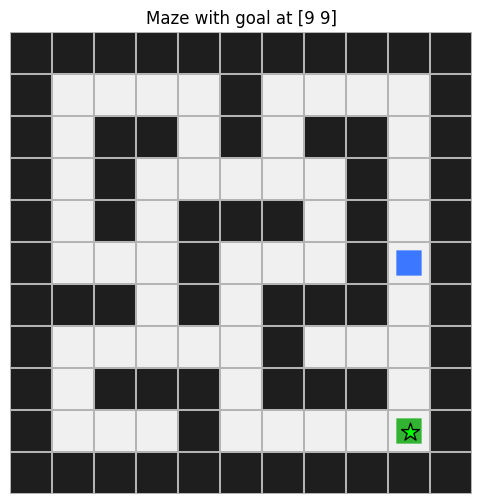

In [2]:
MAZE_LAYOUT = [
    [1,1,1,1,1,1,1,1,1,1,1],
    [1,0,0,0,0,1,0,0,0,0,1],
    [1,0,1,1,0,1,0,1,1,0,1],
    [1,0,1,0,0,0,0,0,1,0,1],
    [1,0,1,0,1,1,1,0,1,0,1],
    [1,0,0,0,1,0,0,0,1,0,1],
    [1,1,1,0,1,0,1,1,1,0,1],
    [1,0,0,0,0,0,1,0,0,0,1],
    [1,0,1,1,1,0,1,1,1,0,1],
    [1,0,0,0,1,0,0,0,0,0,1],
    [1,1,1,1,1,1,1,1,1,1,1],
]

def make_env(goal=(9, 9), slip_prob=0.00, max_horizon=500):
    base = MazeGridWorld(
        maze=MAZE_LAYOUT,
        max_episode_steps=max_horizon,
    )
    env = MazeGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
        reward_mode="simple",
    )
    return env

env = make_env(goal=(9, 9))
obs, info = env.reset()

img = env.unwrapped.render()
goal = env.goal_position

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.scatter(
    goal[0] * 40 + 20,
    goal[1] * 40 + 20,
    c="lime",
    s=180,
    marker="*",
    edgecolors="black",
)
plt.title(f"Maze with goal at {goal}")
plt.axis("off")
plt.show()

## Training Loop across goals and seeds


================ SEED 42 ================

Sampled GOALS for seed 42: [(8, 9), (4, 7), (5, 8), (3, 6), (6, 9), (7, 4), (6, 1), (3, 7)]

----- seed=42, task_idx=0, goal=(8, 9) -----

No previous goal prototype used.
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-49.950 | eval_len=500.0 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-49.825 | eval_len=500.0 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-49.925 | eval_len=500.0 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=-43.563 | eval_len=437.9 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=  

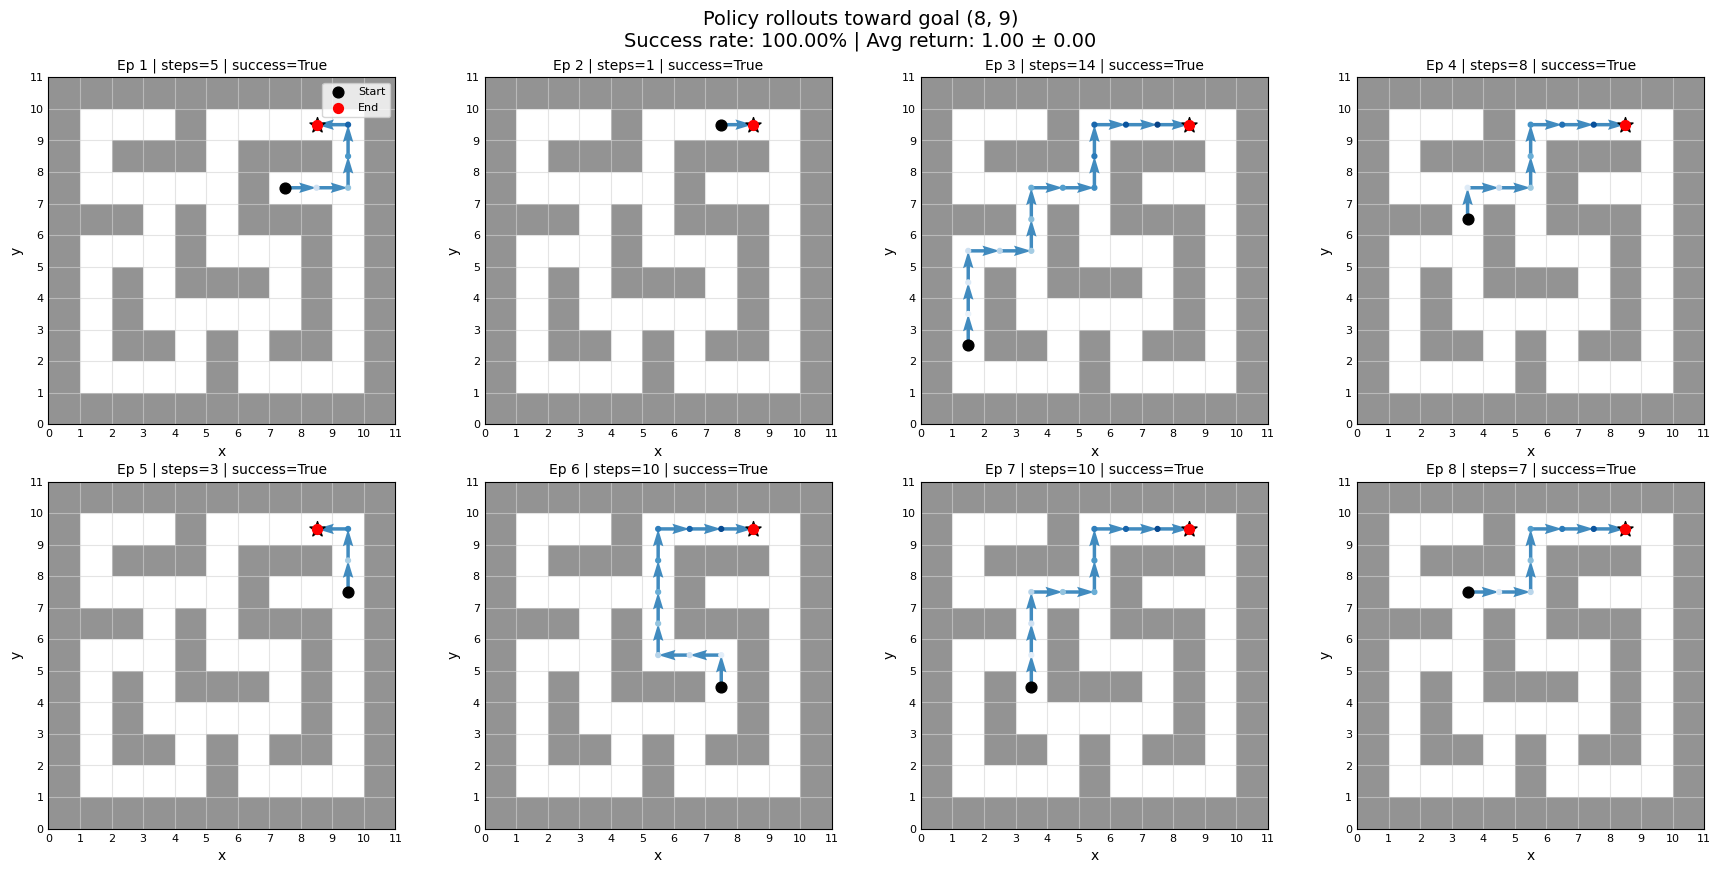

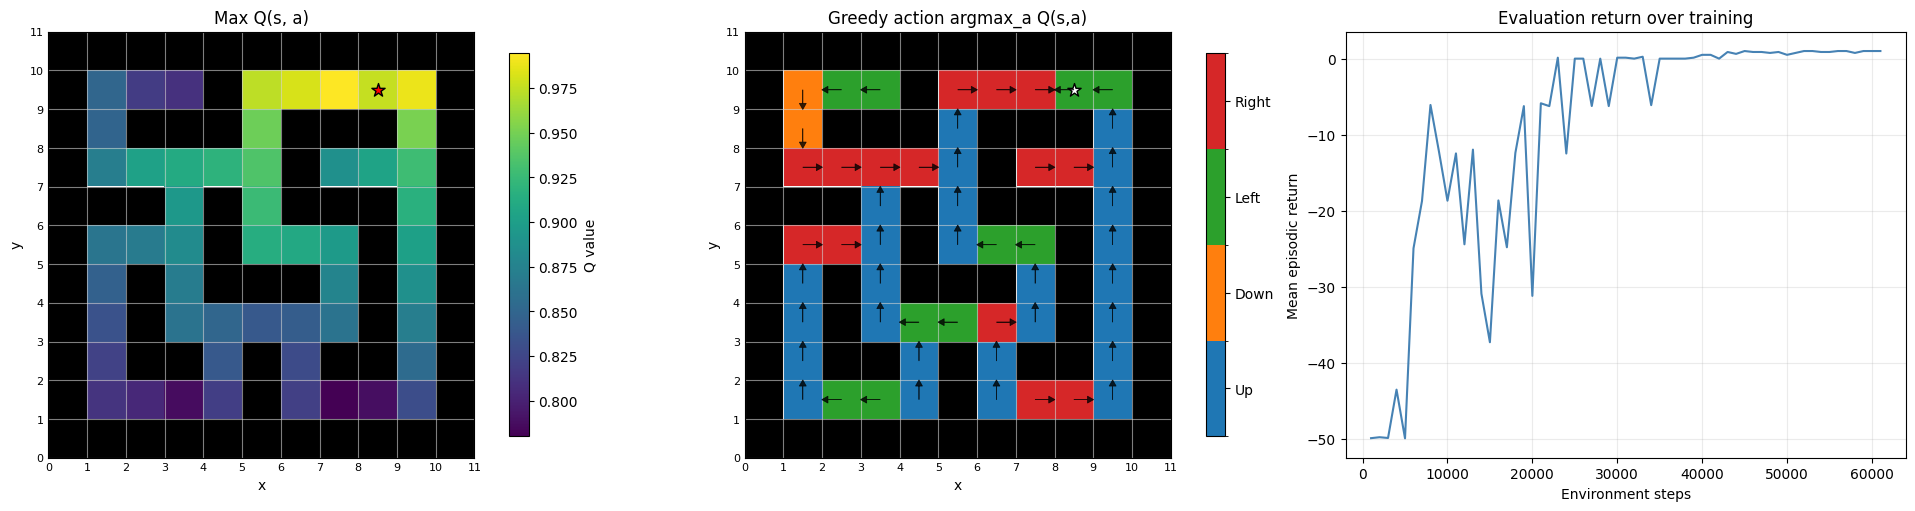

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.7982912 3.2744768 2.9973161 2.8116996 2.7250633]
cumulative variance (first 5 dims): [0.21585026 0.37627077 0.5106838  0.6289645  0.7400684 ]
cos(phi(s,a), psi/task): mean=0.8180, std=0.0747


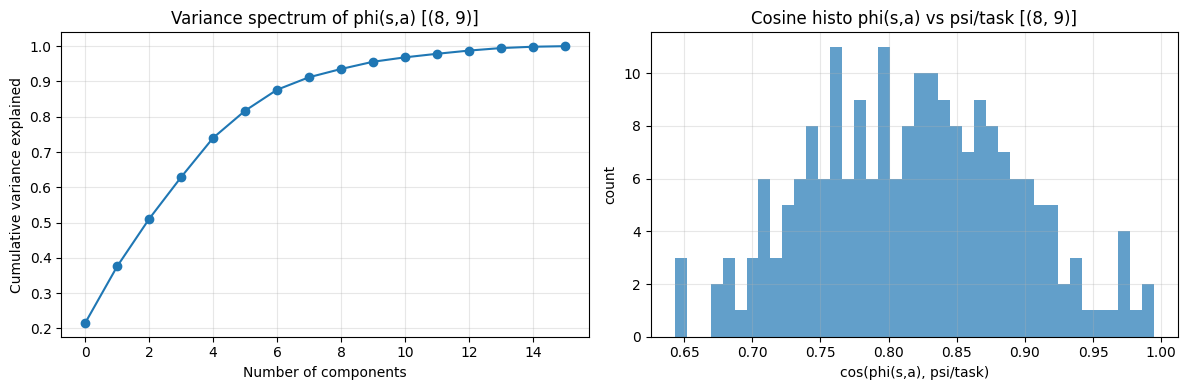


Goal embedding cosine similarity matrix:
     task_0
  task_0      1.000
Finished task_0 | seed=42 | goal=(8, 9) | steps=61000 | time=173.42s | retrieved=none | sa_anchor_sets=1

----- seed=42, task_idx=1, goal=(4, 7) -----

Retrieved previous tasks | indices=[0] | similarities=[-4.4721360206604] | weights=[1.0]
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.375 | eval_len=315.0 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.500 | eval_len=251.5 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=0.625 | eval_len=190.9 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   4000 | eps=0.924 | eval_return=0.375 | eval_len=315.4 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | 

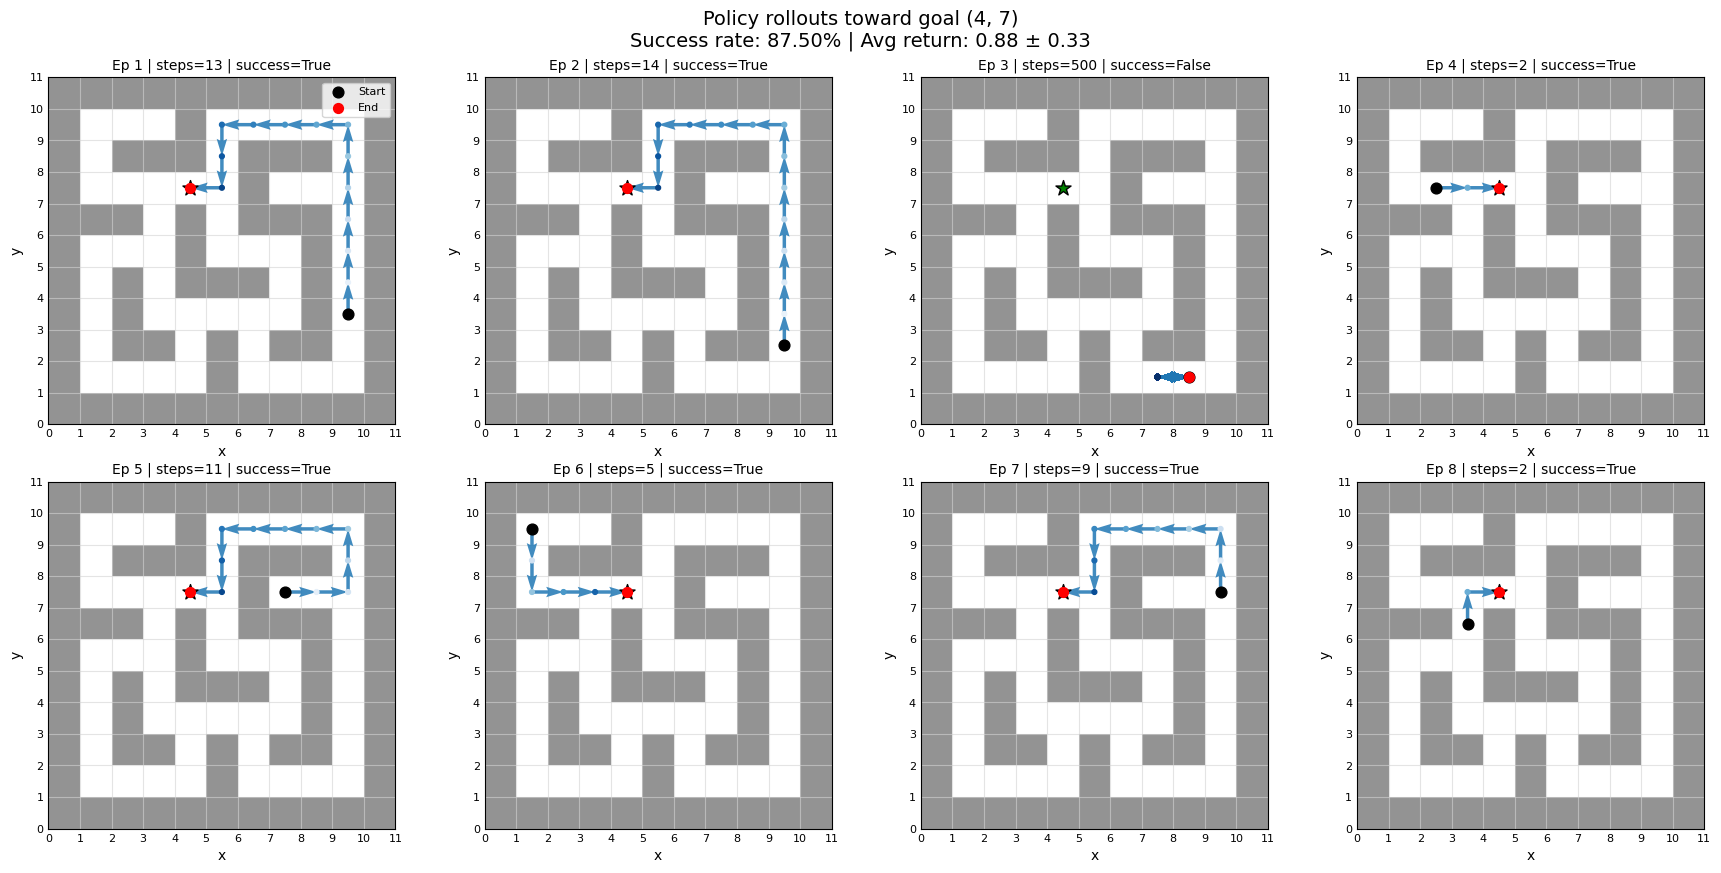

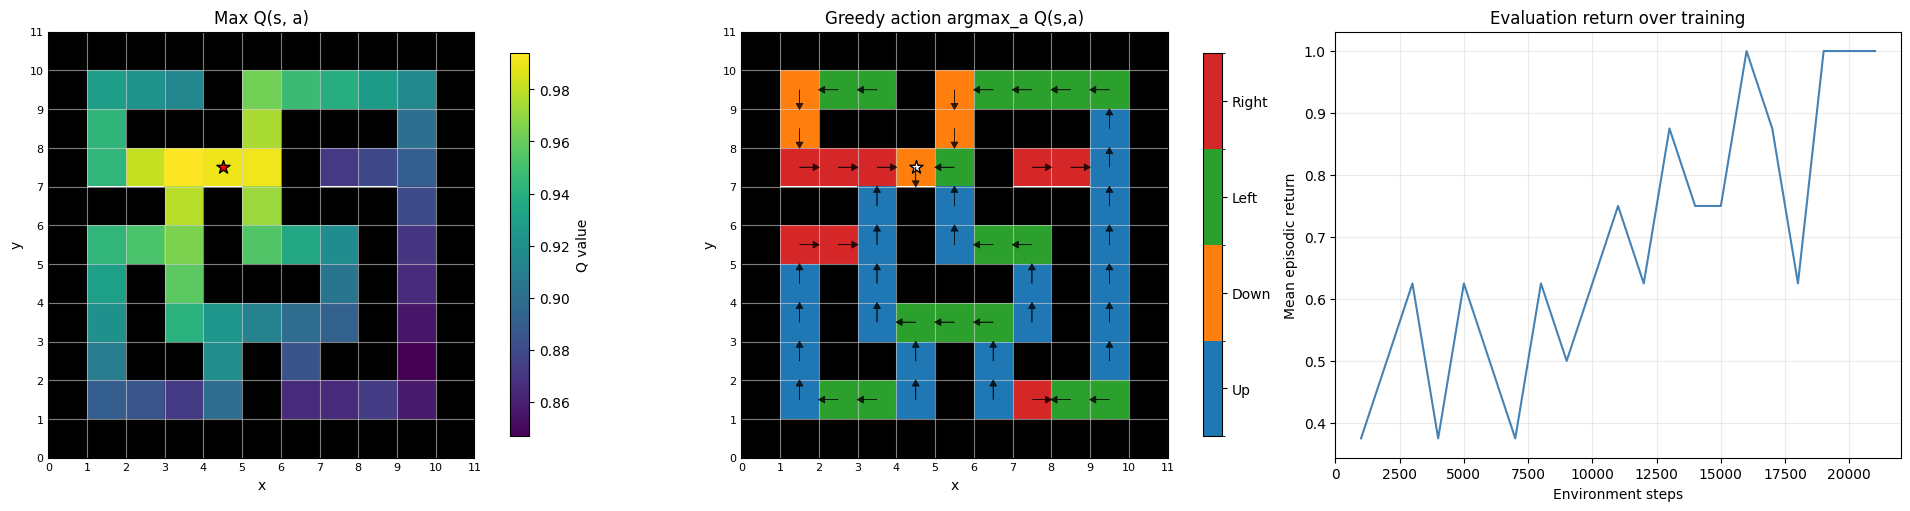

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.2667048 3.121679  2.6977043 2.417074  2.0568535]
cumulative variance (first 5 dims): [0.20906307 0.39997542 0.54255134 0.65700704 0.7398898 ]
cos(phi(s,a), psi/task): mean=0.8627, std=0.0616


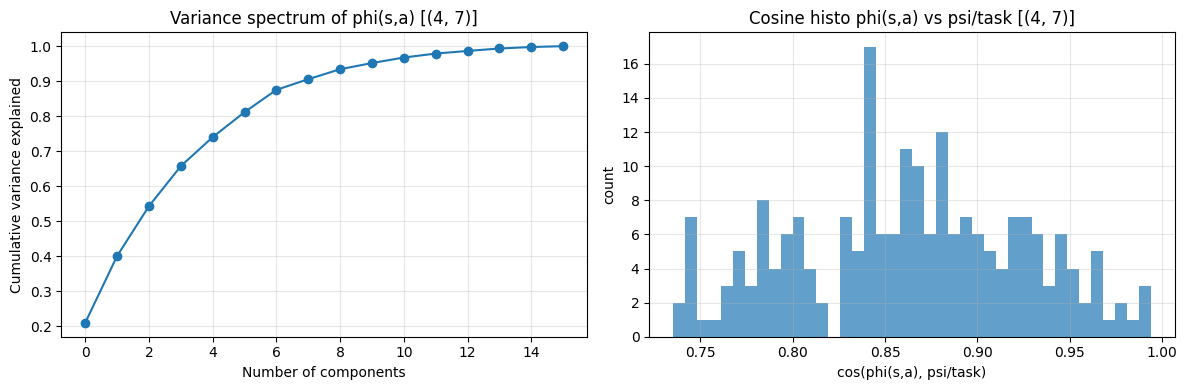


Goal embedding cosine similarity matrix:
     task_0     task_1
  task_0      1.000      0.996
  task_1      0.996      1.000

Off-diagonal mean similarity: 0.996
Off-diagonal min similarity: 0.996
Off-diagonal max similarity: 0.996
Finished task_1 | seed=42 | goal=(4, 7) | steps=21000 | time=47.06s | retrieved=[0] | sa_anchor_sets=2

----- seed=42, task_idx=2, goal=(5, 8) -----

Retrieved previous tasks | indices=[1, 0] | similarities=[-1.4142135381698608, -3.1622776985168457] | weights=[0.9970614314079285, 0.0029385974630713463]
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=-30.463 | eval_len=314.4 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=-36.788 | eval_len=377.0 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   3000 | eps=0.943 | eval_return=-24.238 | eval_len=252.8 |

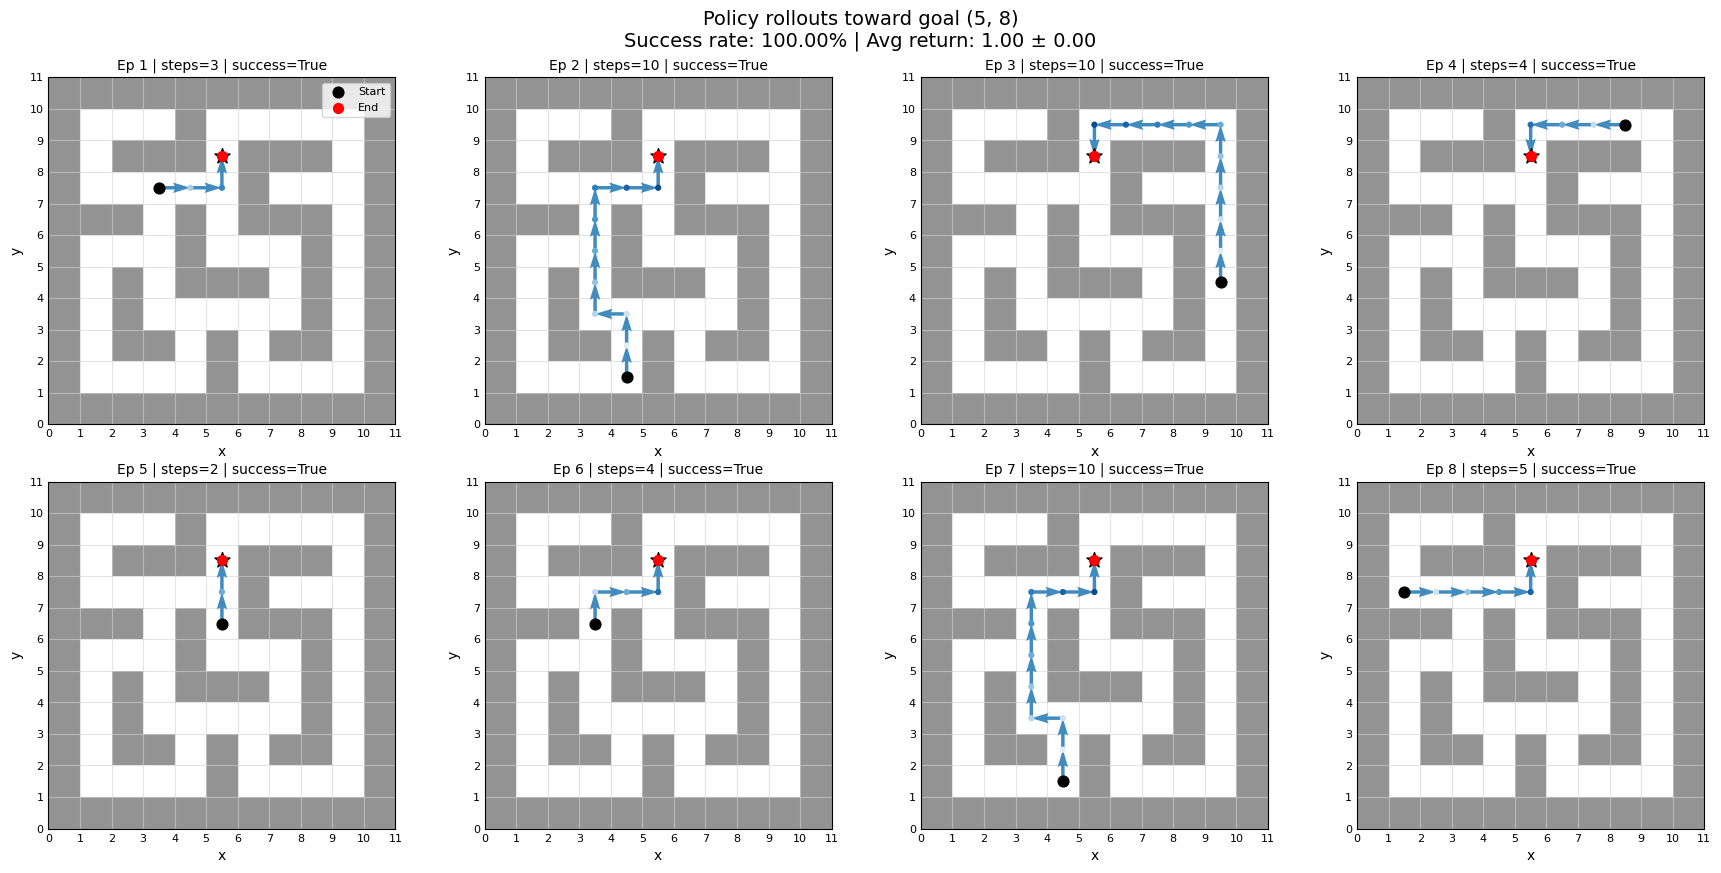

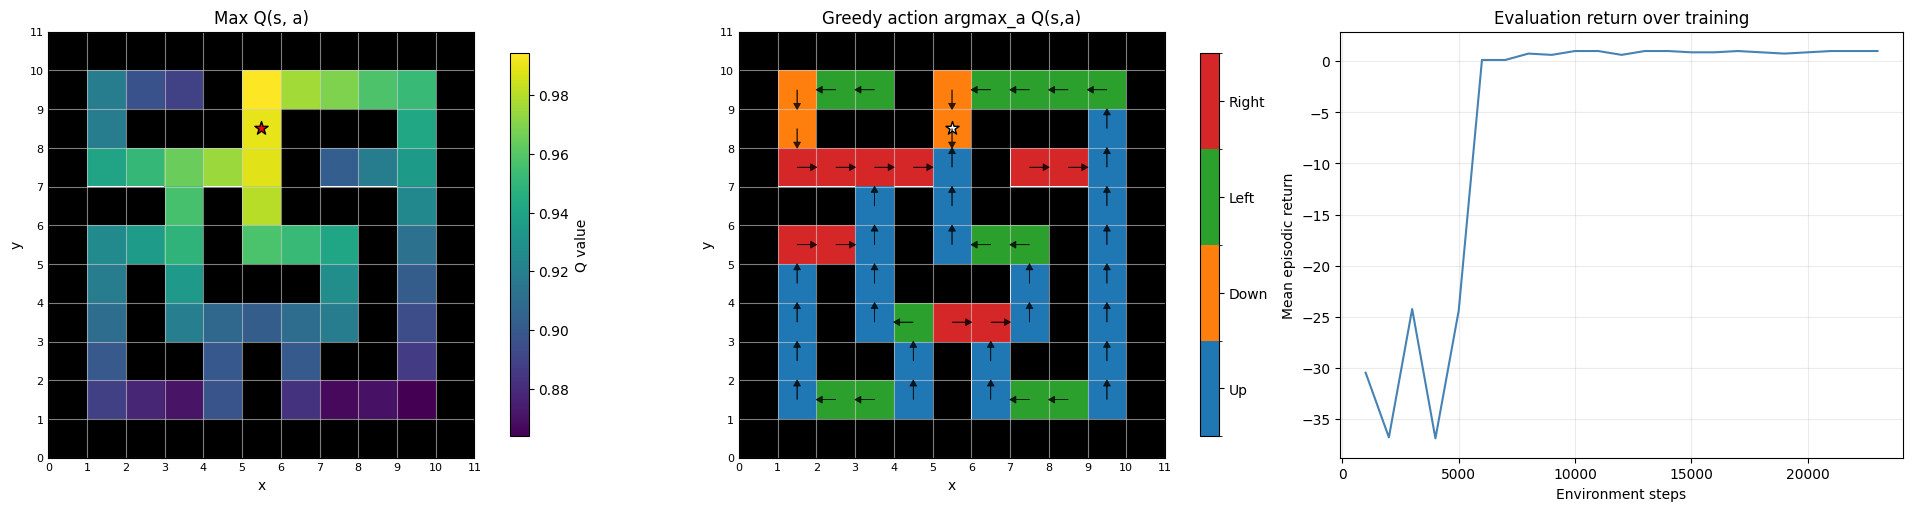

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.339208  2.9744887 2.730508  2.182151  2.0244222]
cumulative variance (first 5 dims): [0.22581616 0.40499747 0.55598986 0.6524255  0.73542404]
cos(phi(s,a), psi/task): mean=0.8671, std=0.0605


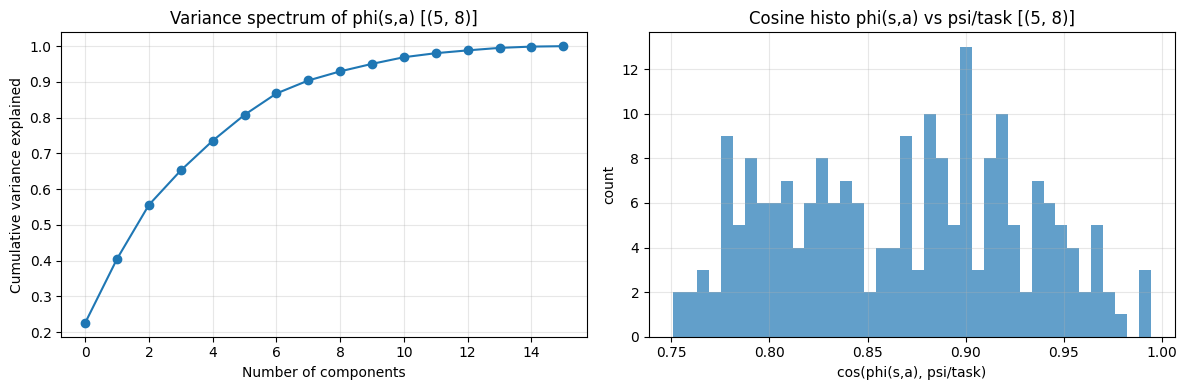


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2
  task_0      1.000      0.996      0.997
  task_1      0.996      1.000      0.996
  task_2      0.997      0.996      1.000

Off-diagonal mean similarity: 0.996
Off-diagonal min similarity: 0.996
Off-diagonal max similarity: 0.997
Finished task_2 | seed=42 | goal=(5, 8) | steps=23000 | time=51.72s | retrieved=[1, 0] | sa_anchor_sets=3

----- seed=42, task_idx=3, goal=(3, 6) -----

Retrieved previous tasks | indices=[1, 2, 0] | similarities=[-1.4142135381698608, -2.8284270763397217, -5.830951690673828] | weights=[0.9911109209060669, 0.008888705633580685, 4.001651063845202e-07]
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.250 | eval_len=376.1 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.125 | eval_len=438.6 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-s

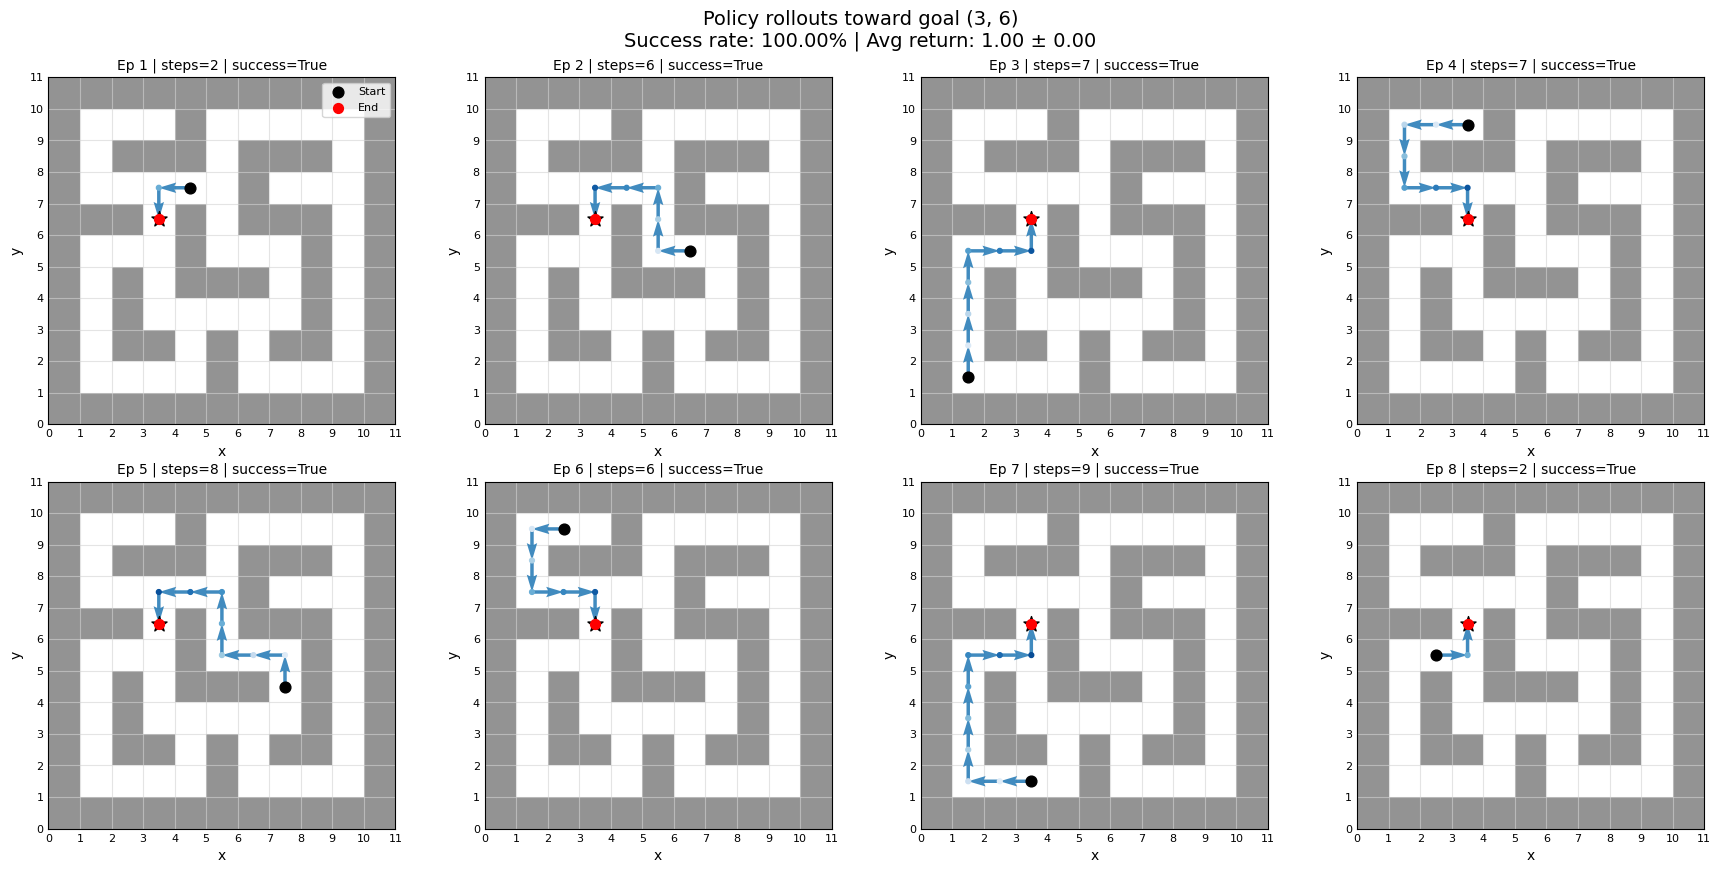

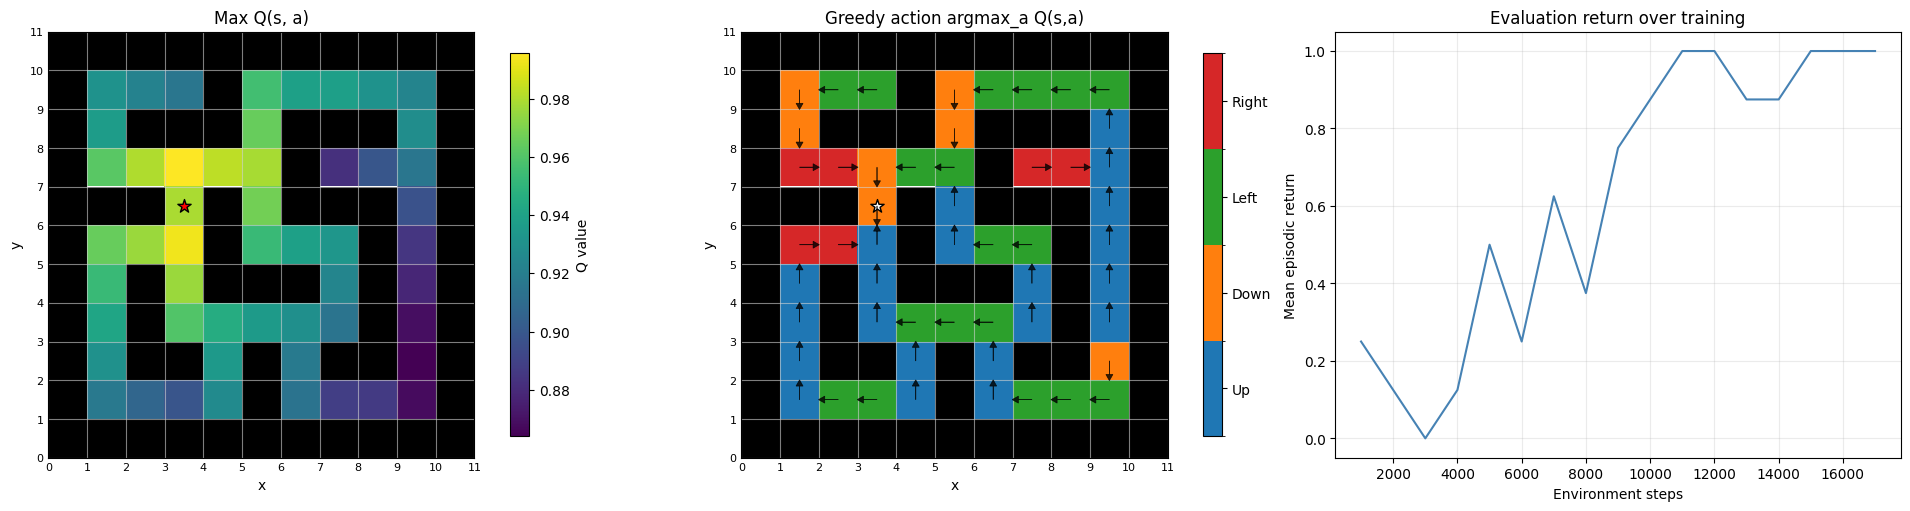

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.380882  2.8811982 2.6742187 2.0768764 1.8102882]
cumulative variance (first 5 dims): [0.25016657 0.43185008 0.58836764 0.6827717  0.7544957 ]
cos(phi(s,a), psi/task): mean=0.8776, std=0.0589


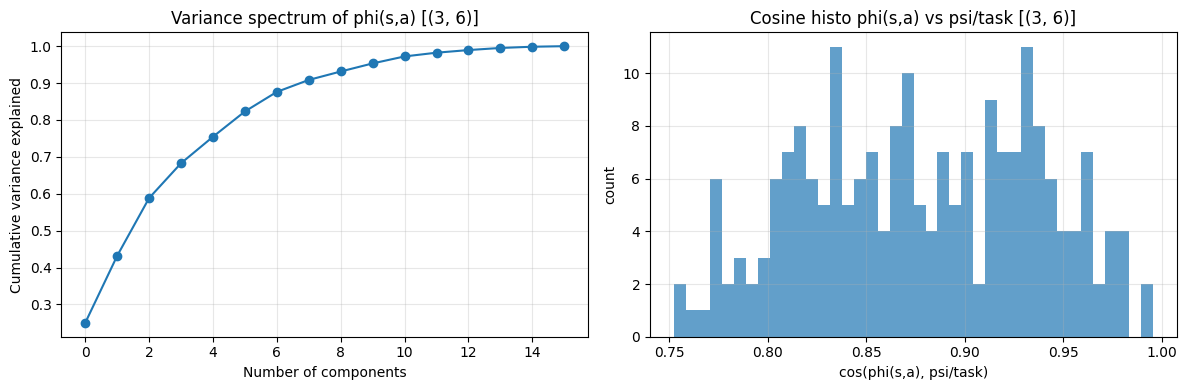


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3
  task_0      1.000      0.996      0.997      0.993
  task_1      0.996      1.000      0.996      0.999
  task_2      0.997      0.996      1.000      0.995
  task_3      0.993      0.999      0.995      1.000

Off-diagonal mean similarity: 0.996
Off-diagonal min similarity: 0.993
Off-diagonal max similarity: 0.999
Finished task_3 | seed=42 | goal=(3, 6) | steps=17000 | time=38.25s | retrieved=[1, 2, 0] | sa_anchor_sets=4

----- seed=42, task_idx=4, goal=(6, 9) -----

Retrieved previous tasks | indices=[2, 0, 1] | similarities=[-1.4142135381698608, -2.0, -2.8284270763397217] | weights=[0.8689078092575073, 0.12329940497875214, 0.007792735937982798]
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.375 | eval_len=314.5 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWeight=0.0000e+00 | SA-stability=0.0000e+00 | projection=n/a
[DQN-factorised] step=   2000 | eps=0.962 | eval_return=0.125 | eva

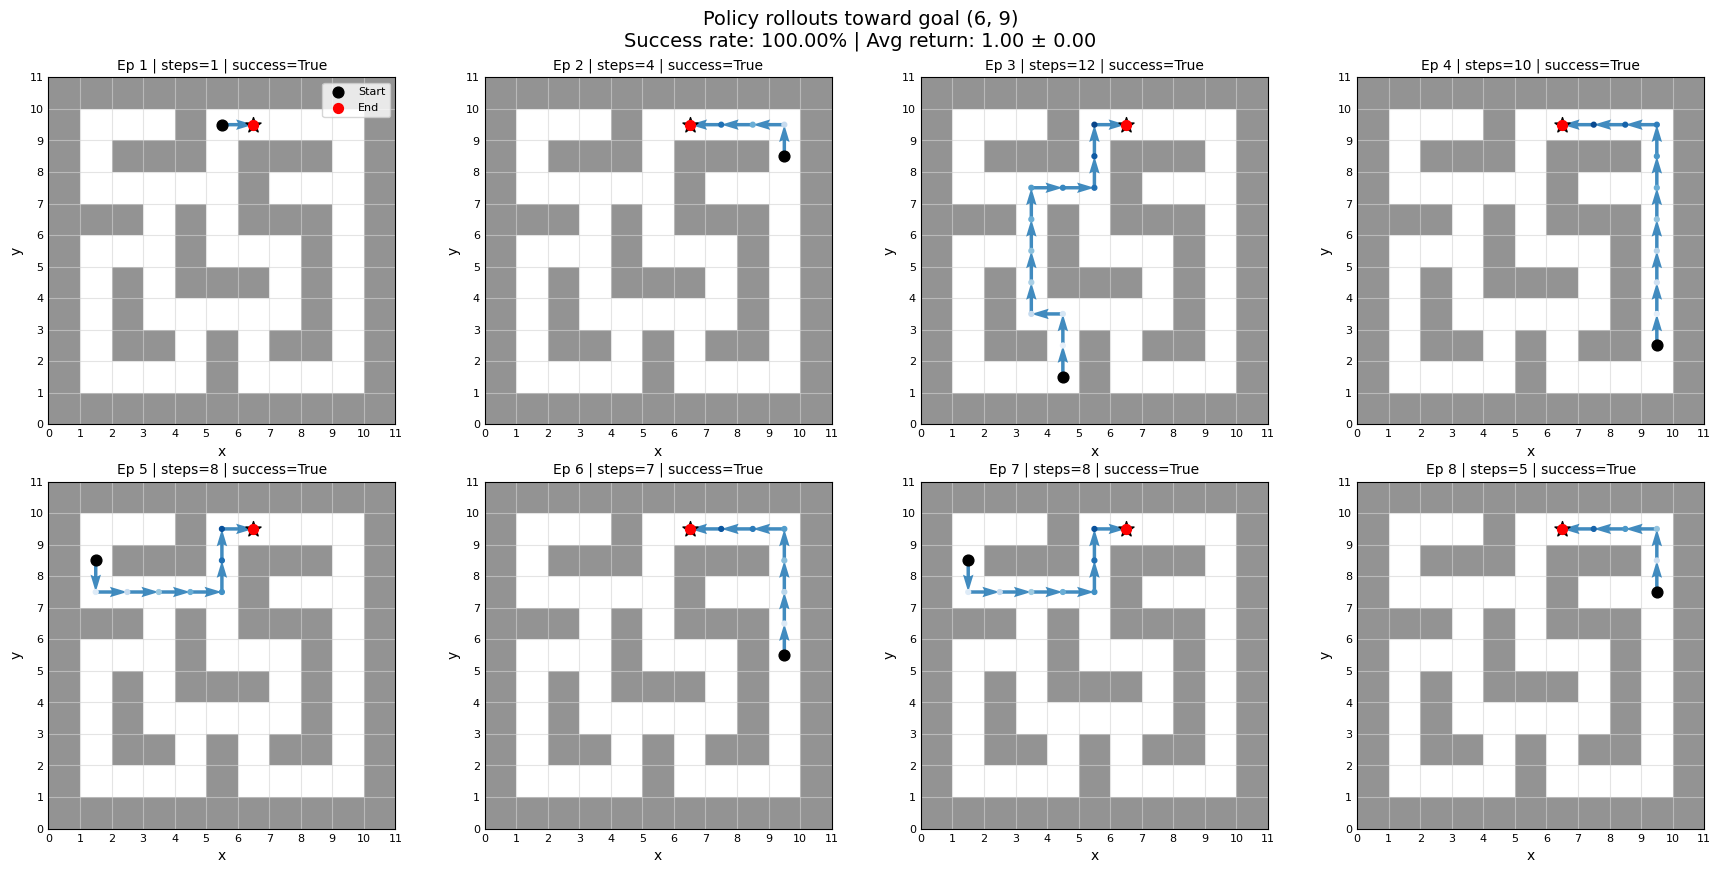

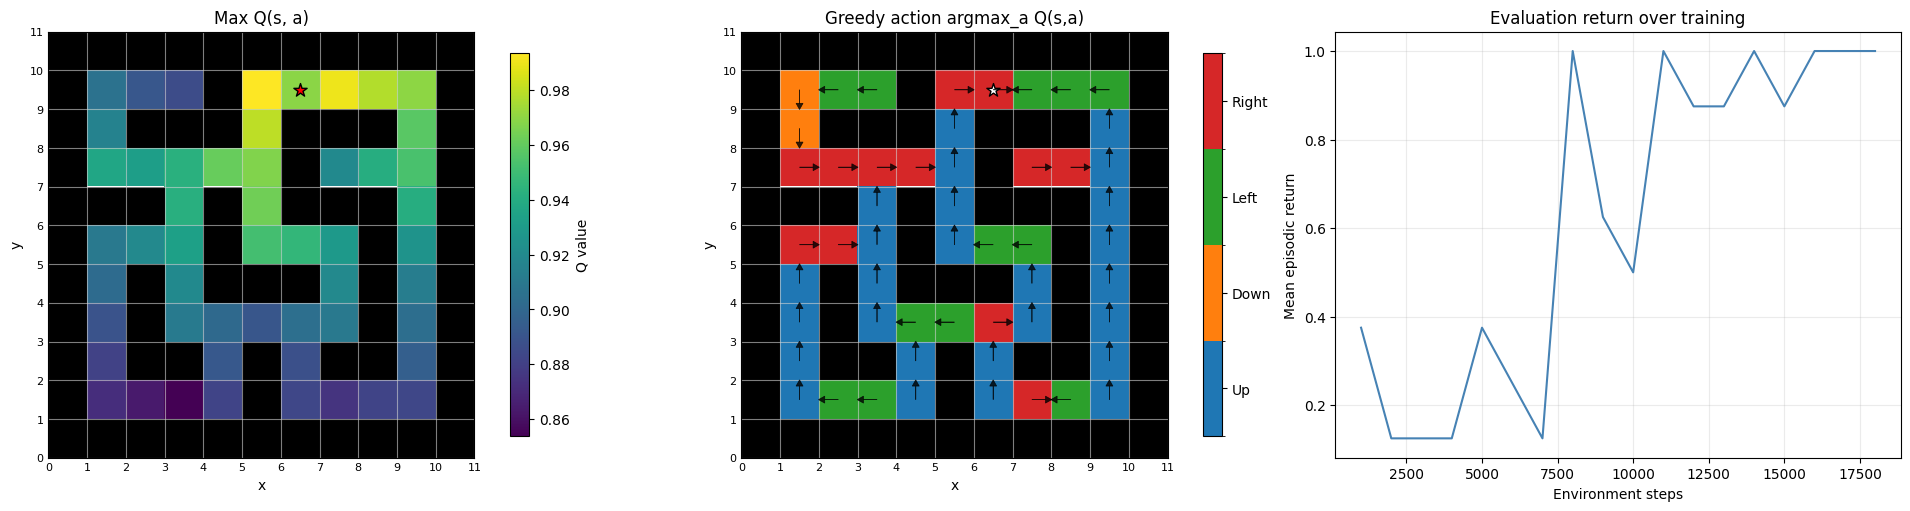

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4581704 3.0094957 2.7110746 2.2069523 1.9735855]
cumulative variance (first 5 dims): [0.23996697 0.42170516 0.56918806 0.6669218  0.7450793 ]
cos(phi(s,a), psi/task): mean=0.8639, std=0.0602


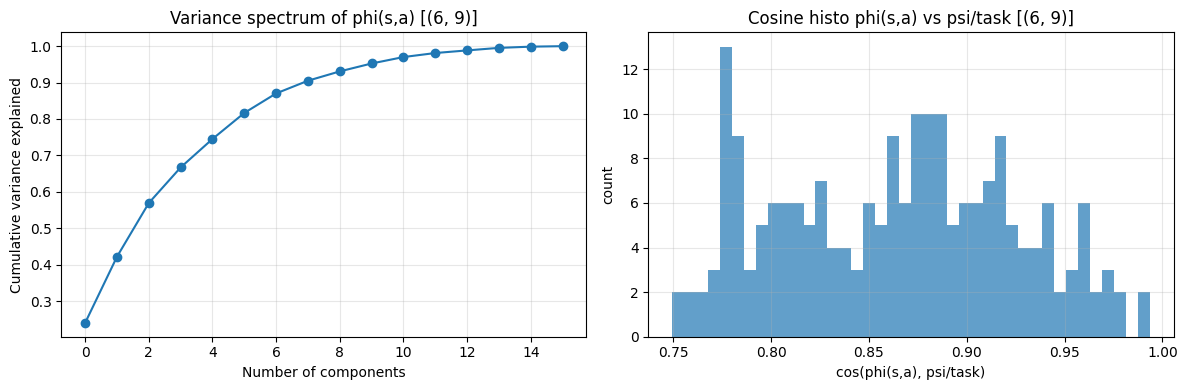


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4
  task_0      1.000      0.996      0.997      0.993      0.995
  task_1      0.996      1.000      0.996      0.999      0.987
  task_2      0.997      0.996      1.000      0.995      0.996
  task_3      0.993      0.999      0.995      1.000      0.987
  task_4      0.995      0.987      0.996      0.987      1.000

Off-diagonal mean similarity: 0.994
Off-diagonal min similarity: 0.987
Off-diagonal max similarity: 0.999
Finished task_4 | seed=42 | goal=(6, 9) | steps=18000 | time=43.81s | retrieved=[2, 0, 1] | sa_anchor_sets=5

----- seed=42, task_idx=5, goal=(7, 4) -----

Retrieved previous tasks | indices=[1, 3, 2] | similarities=[-4.242640495300293, -4.4721360206604, -4.4721360206604] | weights=[0.5179517865180969, 0.24102413654327393, 0.24102413654327393]
[DQN-factorised] step=   1000 | eps=0.981 | eval_return=0.250 | eval_len=375.5 | TD=0.0000e+00 | GoalAnchor=0.0000e+00 | AnchorWe

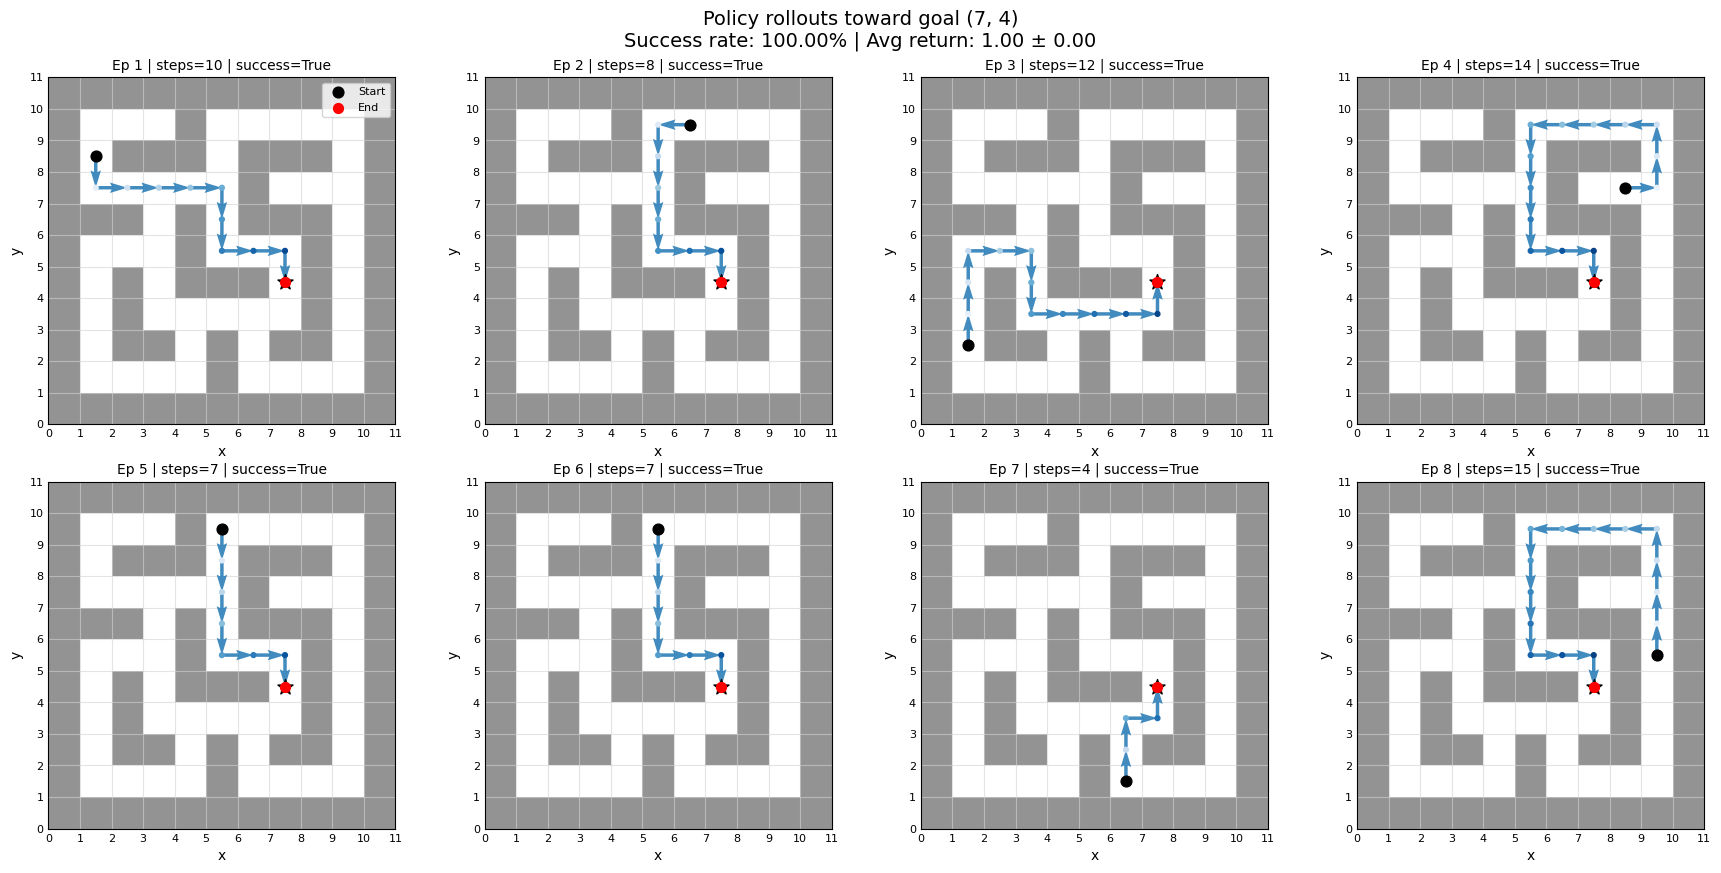

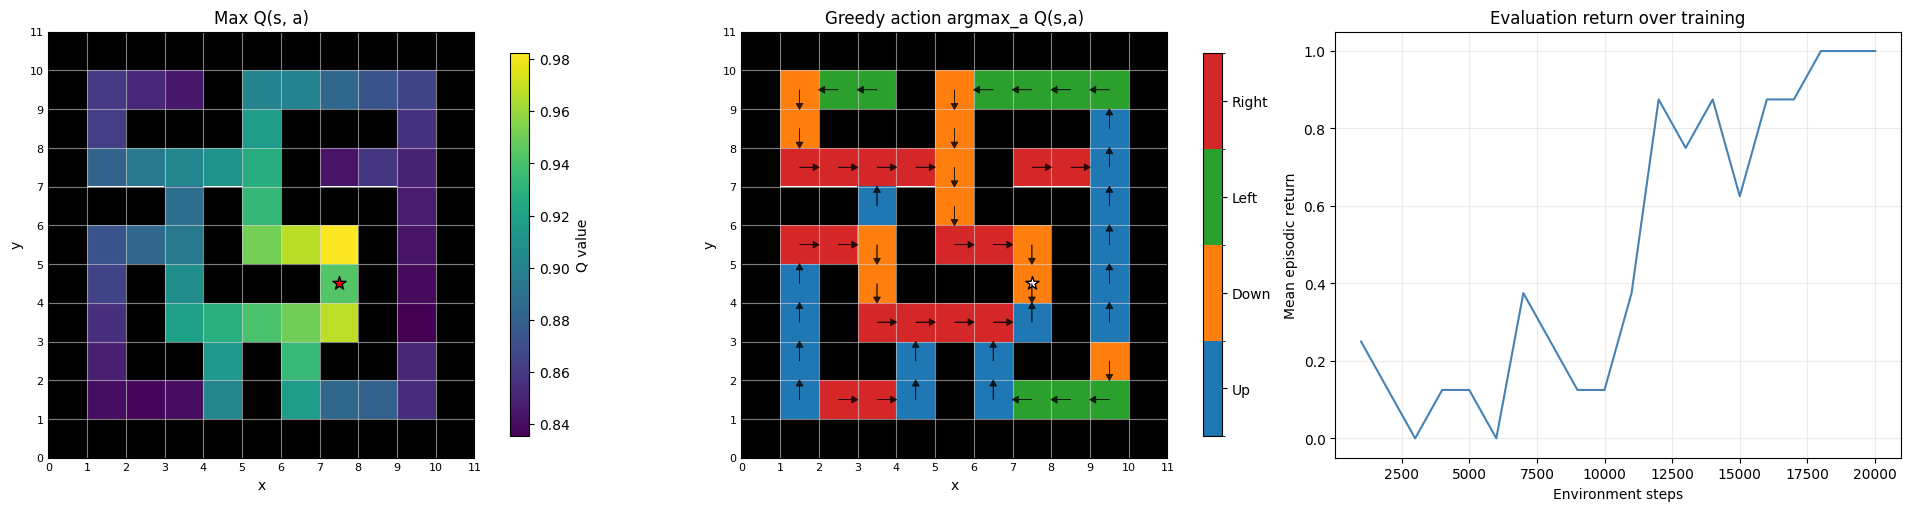

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6739566 3.0141494 2.7006292 2.4125626 2.159457 ]
cumulative variance (first 5 dims): [0.24395329 0.4081514  0.53996754 0.6451627  0.7294433 ]
cos(phi(s,a), psi/task): mean=0.8317, std=0.0631


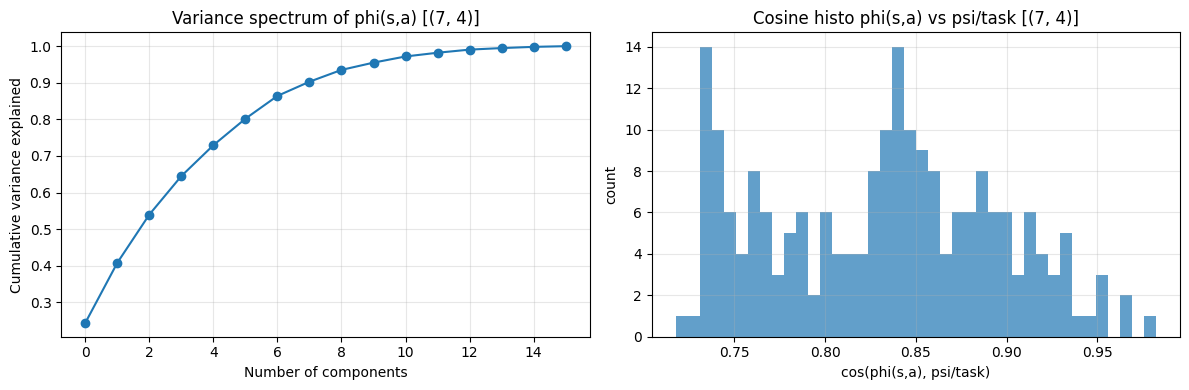


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5
  task_0      1.000      0.996      0.997      0.993      0.995      0.958
  task_1      0.996      1.000      0.996      0.999      0.987      0.962
  task_2      0.997      0.996      1.000      0.995      0.996      0.964
  task_3      0.993      0.999      0.995      1.000      0.987      0.959
  task_4      0.995      0.987      0.996      0.987      1.000      0.962
  task_5      0.958      0.962      0.964      0.959      0.962      1.000

Off-diagonal mean similarity: 0.983
Off-diagonal min similarity: 0.958
Off-diagonal max similarity: 0.999
Finished task_5 | seed=42 | goal=(7, 4) | steps=20000 | time=55.02s | retrieved=[1, 3, 2] | sa_anchor_sets=6

----- seed=42, task_idx=6, goal=(6, 1) -----

Retrieved previous tasks | indices=[5, 3, 1] | similarities=[-3.1622776985168457, -5.830951690673828, -6.324555397033691] | weights=[0.9998365640640259, 0.00013697080430574715, 2

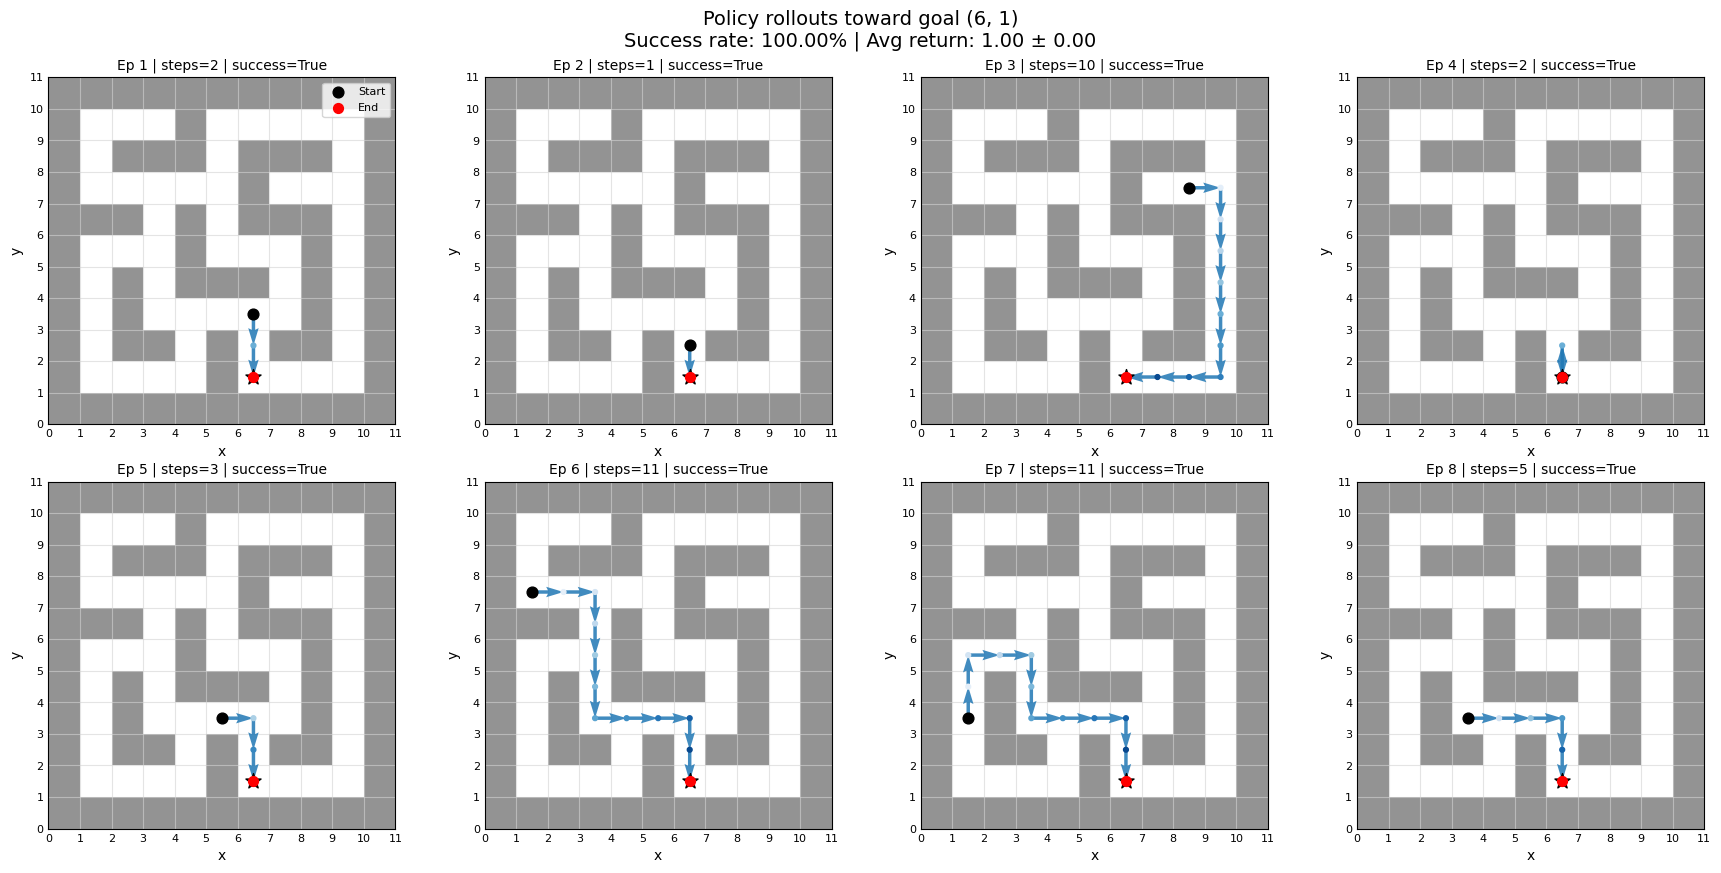

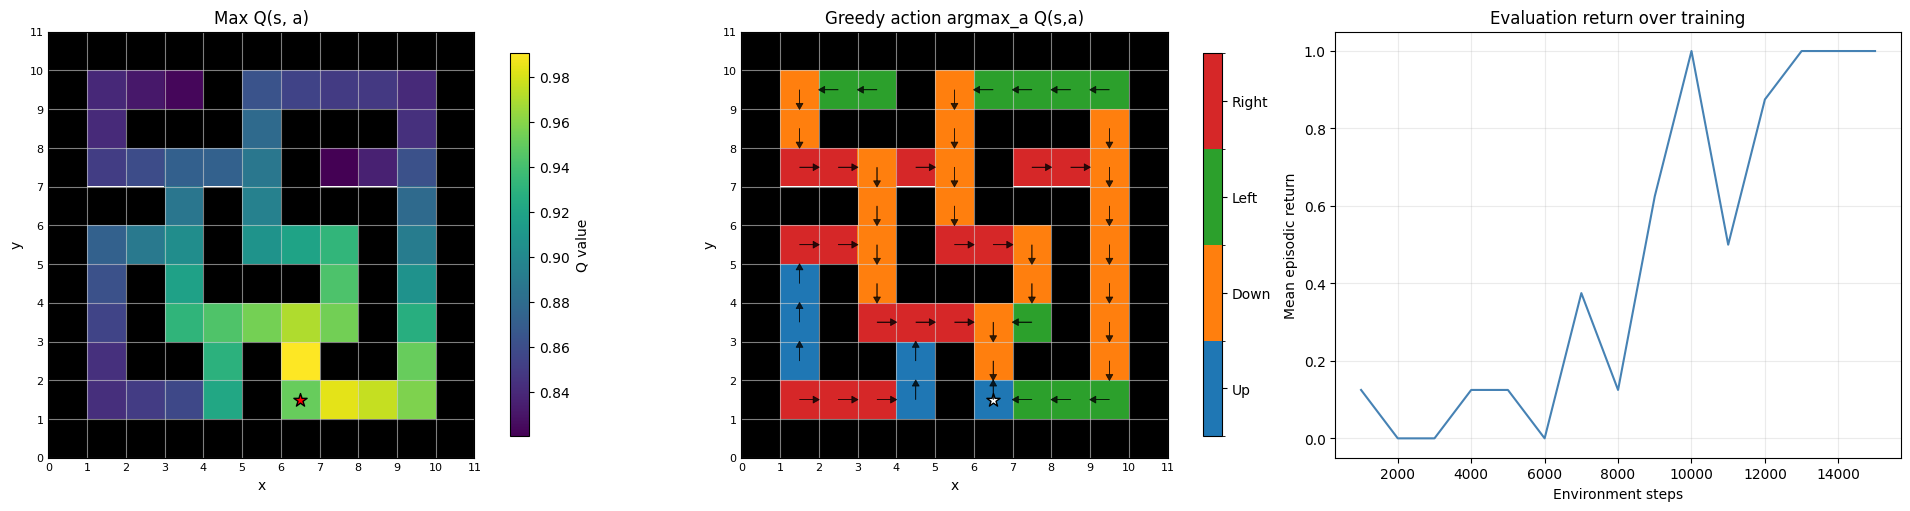

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.6731732 2.8522978 2.5142457 2.152329  2.0905826]
cumulative variance (first 5 dims): [0.26422828 0.42355415 0.54735166 0.6380739  0.72366554]
cos(phi(s,a), psi/task): mean=0.8341, std=0.0691


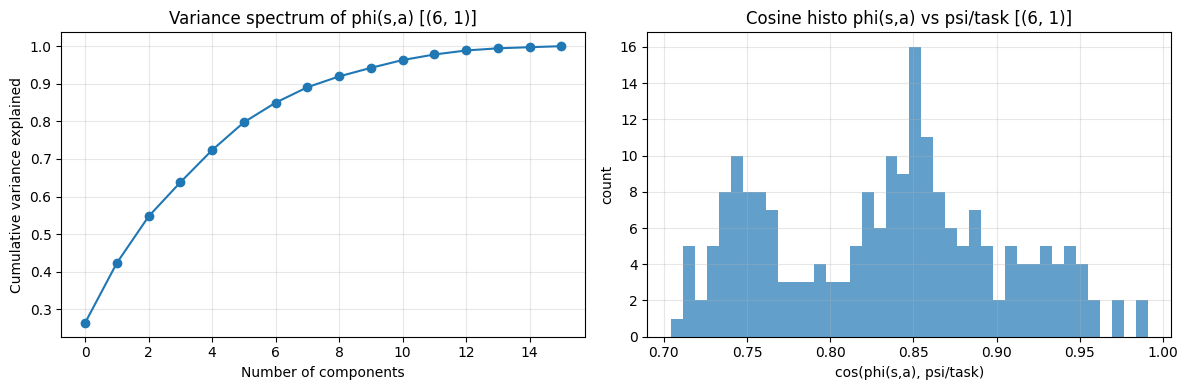


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6
  task_0      1.000      0.996      0.997      0.993      0.995      0.958      0.936
  task_1      0.996      1.000      0.996      0.999      0.987      0.962      0.943
  task_2      0.997      0.996      1.000      0.995      0.996      0.964      0.944
  task_3      0.993      0.999      0.995      1.000      0.987      0.959      0.944
  task_4      0.995      0.987      0.996      0.987      1.000      0.962      0.943
  task_5      0.958      0.962      0.964      0.959      0.962      1.000      0.984
  task_6      0.936      0.943      0.944      0.944      0.943      0.984      1.000

Off-diagonal mean similarity: 0.973
Off-diagonal min similarity: 0.936
Off-diagonal max similarity: 0.999
Finished task_6 | seed=42 | goal=(6, 1) | steps=15000 | time=38.43s | retrieved=[5, 3, 1] | sa_anchor_sets=7

----- seed=42, task_idx=7, goal=(3, 7) -----

Retrieved previ

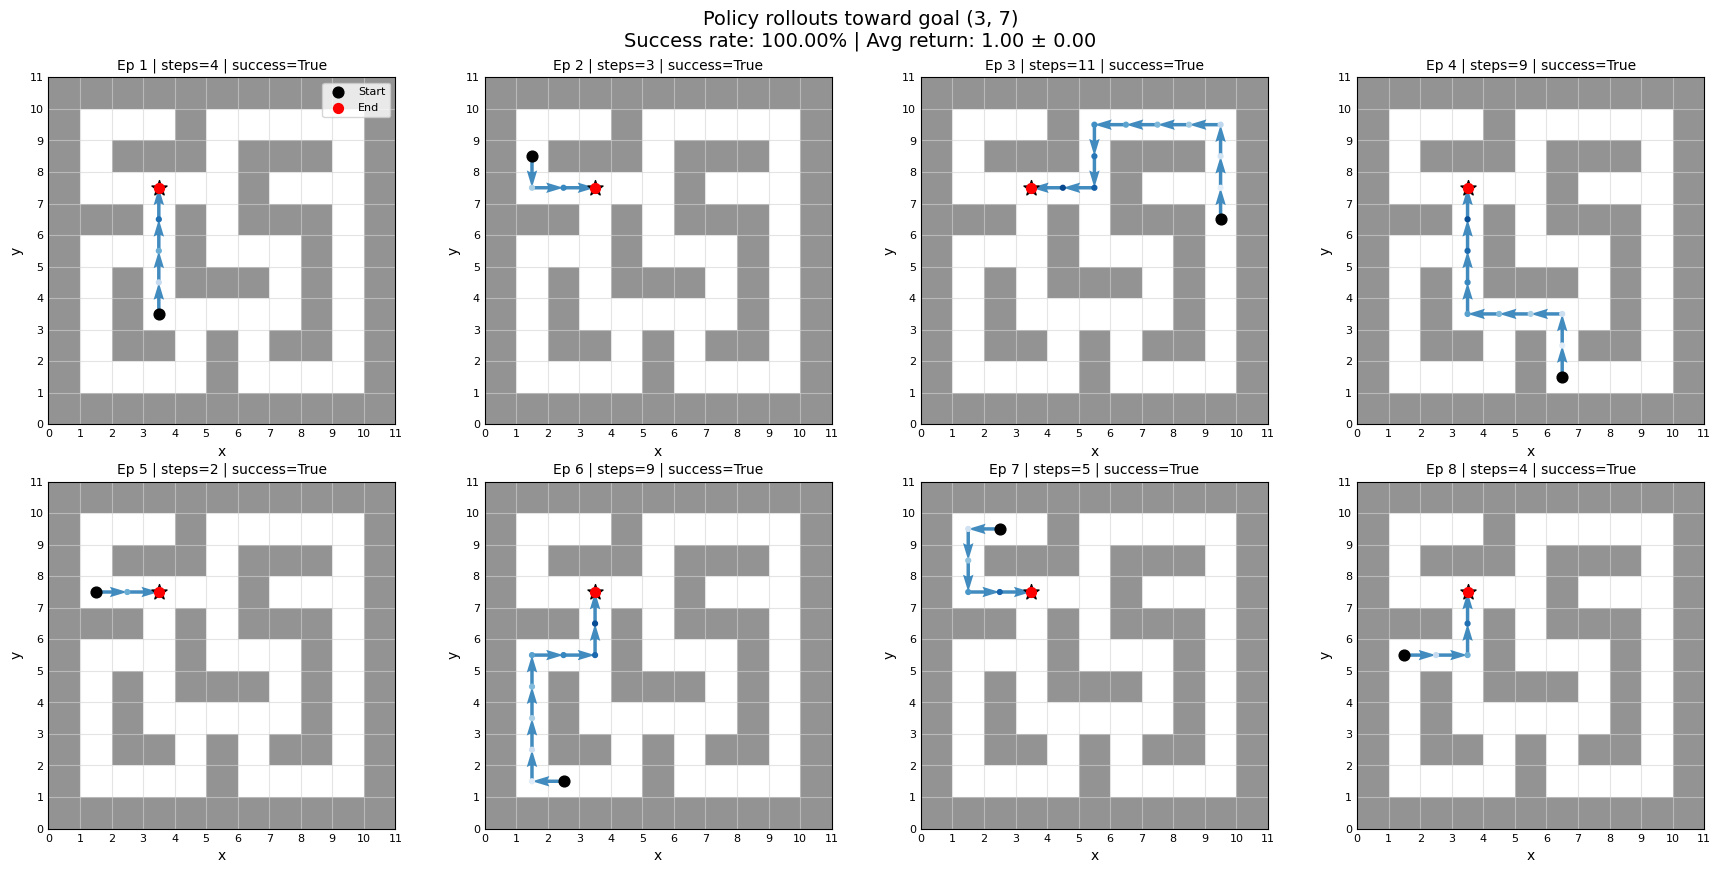

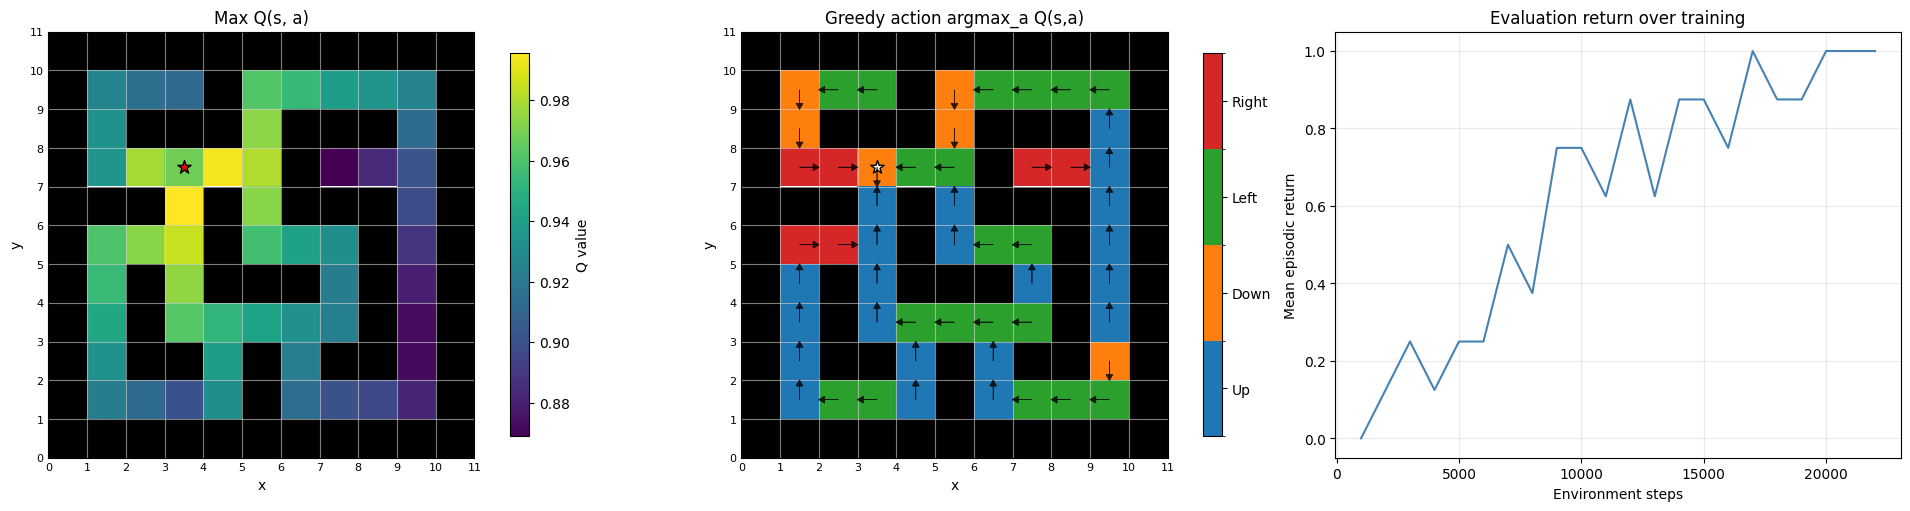

Embedding mode: all_discrete
states_base: (52, 2)
coords_base: (52, 2)
phi(s,a) base: (52, 4, 16)
psi(z) / task code base: (1, 16)
phi(s,a) norms: mean=1.0000, std=0.0000
top 5 singular values: [3.4632454 2.8824205 2.4805346 2.0977614 1.900892 ]
cumulative variance (first 5 dims): [0.258101   0.43688875 0.5692966  0.6639934  0.7417501 ]
cos(phi(s,a), psi/task): mean=0.8752, std=0.0612


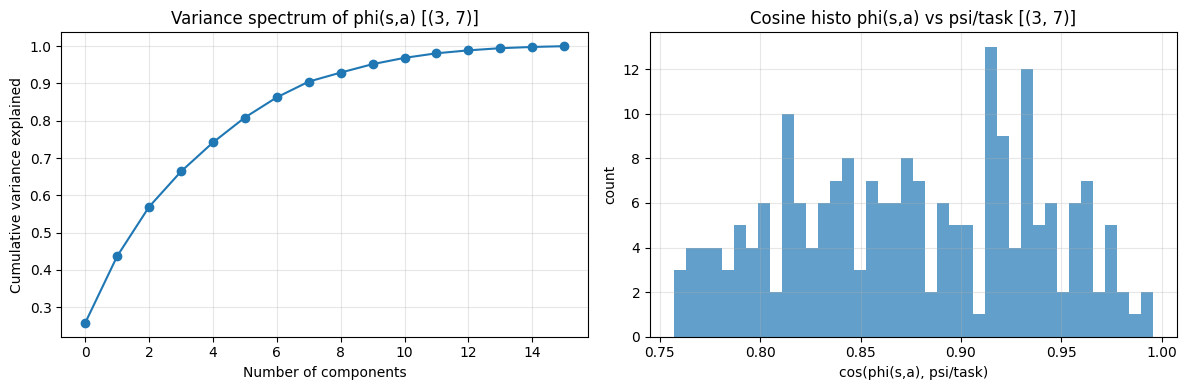


Goal embedding cosine similarity matrix:
     task_0     task_1     task_2     task_3     task_4     task_5     task_6     task_7
  task_0      1.000      0.996      0.997      0.993      0.995      0.958      0.936      0.990
  task_1      0.996      1.000      0.996      0.999      0.987      0.962      0.943      0.996
  task_2      0.997      0.996      1.000      0.995      0.996      0.964      0.944      0.994
  task_3      0.993      0.999      0.995      1.000      0.987      0.959      0.944      0.997
  task_4      0.995      0.987      0.996      0.987      1.000      0.962      0.943      0.986
  task_5      0.958      0.962      0.964      0.959      0.962      1.000      0.984      0.965
  task_6      0.936      0.943      0.944      0.944      0.943      0.984      1.000      0.952
  task_7      0.990      0.996      0.994      0.997      0.986      0.965      0.952      1.000

Off-diagonal mean similarity: 0.976
Off-diagonal min similarity: 0.936
Off-diagonal max simi

In [3]:
SEEDS = [42]
NUM_GOALS = 8

BUFFER_CAPACITY = 100000
LR_SA = 1e-3
LR_GOAL = 2e-3

TOTAL_STEPS = 100000
WARMUP_STEPS = 5000
BATCH_SIZE = 256
GAMMA = 0.99
TAU = 0.005

EPS_START = 1.0
EPS_END = 0.05
EPS_DECAY_STEPS = 50000
TRAIN_FREQ = 3

TASK_TYPE = "maze"
GOAL_TOP_K = 3
GOAL_SIMILARITY_TEMPERATURE = 0.3
GOAL_MINIMUM_SIMILARITY = None

GOAL_ANCHOR_COEF = 0.1
GOAL_ANCHOR_STEPS = 2000

sa_keywords_local = ["sa_encoder"]
goal_keywords_local = ["goal_encoder"]

overall_results = {
    task_idx: {
        "goals_by_seed": {},
        "eval_returns": [],
        "min_steps": [],
        "min_time": [],
        "task_embeddings": [],
        "sa_embeddings": [],
        "sa_fixed_probe_embeddings": [],
        "sa_batches_final": [],
        "sa_weight_change": [],
        "goal_weight_change": [],
        "retrieval": [],
    }
    for task_idx in range(NUM_GOALS)
}

goals_by_seed = {}
final_q_networks = {}
final_q_target_networks = {}
weight_history_by_seed = {}
seed_task_memories = {}
seed_retrieval_histories = {}

free_cells = get_free_cells(MAZE_LAYOUT)


# ============================================================
# TRAIN ACROSS SEEDS
# ============================================================

for seed in SEEDS:
    print(f"\n================ SEED {seed} ================\n")

    set_seed(seed)

    goal_rng = np.random.default_rng(seed)

    GOALS = sample_goals(
        NUM_GOALS,
        goal_rng,
        cells=free_cells,
    )

    goals_by_seed[seed] = list(GOALS)

    for task_idx, goal in enumerate(GOALS):
        overall_results[task_idx]["goals_by_seed"][seed] = goal

    print(f"Sampled GOALS for seed {seed}: {GOALS}")

    env_tmp = make_env(goal=GOALS[0])
    obs_dim = env_tmp.observation_space.shape[0]
    num_actions = env_tmp.action_space.n
    env_tmp.close()

    q_net = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target = FactorisedDQN_QNetwork(
        obs_dim=obs_dim,
        num_actions=num_actions,
        goal_dim=2,
        hidden_dim=64,
        rep_dim=16,
    ).to(DEVICE)

    q_target.load_state_dict(q_net.state_dict())

    for p in q_net.parameters():
        p.requires_grad_(True)

    for p in q_target.parameters():
        p.requires_grad_(False)

    # Existing SA-stability memory.
    embedding_memory = {
        "sa_anchors": [],
    }

    # New structured goal/task memory.
    task_memory = []

    # Existing lists used by plotting functions.
    task_embedding_memory = []
    task_labels = []

    # Retrieval diagnostics.
    retrieval_history = []

    # Weight snapshots.
    weight_history = []
    
    for task_idx, goal in enumerate(GOALS):
        task_label = f"task_{task_idx}"

        print(
            f"\n----- seed={seed}, task_idx={task_idx}, "
            f"goal={goal} -----\n"
        )

        for p in q_net.parameters():
            p.requires_grad_(True)


        # ----------------------------------------------------
        # Retrieve a prototype from previous tasks
        # ----------------------------------------------------

        retrieval = retrieve_similar_task_embeddings(
            new_raw_task=goal,
            task_type=TASK_TYPE,
            task_memory=task_memory,
            top_k=GOAL_TOP_K,
            similarity_temperature=GOAL_SIMILARITY_TEMPERATURE,
            minimum_similarity=GOAL_MINIMUM_SIMILARITY,
        )

        if retrieval is None:
            retrieved_prototype = None

            print("No previous goal prototype used.")

            retrieval_record = {
                "task_idx": task_idx,
                "task_label": task_label,
                "goal": np.asarray(goal, dtype=np.float32).copy(),
                "retrieved": False,
                "indices": [],
                "similarities": [],
                "weights": [],
            }

        else:
            retrieved_prototype = retrieval["prototype"]

            retrieved_indices = retrieval["indices"].tolist()
            retrieved_similarities = retrieval["similarities"].tolist()
            retrieved_weights = retrieval["weights"].tolist()

            print(
                f"Retrieved previous tasks | "
                f"indices={retrieved_indices} | "
                f"similarities={retrieved_similarities} | "
                f"weights={retrieved_weights}"
            )

            retrieval_record = {
                "task_idx": task_idx,
                "task_label": task_label,
                "goal": np.asarray(goal, dtype=np.float32).copy(),
                "retrieved": True,
                "indices": retrieved_indices,
                "similarities": retrieved_similarities,
                "weights": retrieved_weights,
            }

        retrieval_history.append(retrieval_record)


        # ----------------------------------------------------
        # Snapshot before training
        # ----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=task_label,
                stage_label=f"{task_label}_before_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )


        # ----------------------------------------------------
        # Train current task
        # ----------------------------------------------------

        train_env = make_env(goal=goal)

        (
            q_net,
            q_target,
            eval_returns,
            min_steps,
            min_time,
            task_embedding,
            sa_embedding_mean,
            sa_embedding_fixed,
            sa_batch_final,
            buffer,
        ) = dqn_train_new(
            seed=seed + task_idx,
            q_network=q_net,
            q_target_network=q_target,
            env=train_env,
            make_env=make_env,
            buffer_capacity=BUFFER_CAPACITY,
            lr_sa=LR_SA,
            lr_goal=LR_GOAL,
            obs_dim=obs_dim,
            device=DEVICE,
            total_steps=TOTAL_STEPS,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            gamma=GAMMA,
            tau=TAU,
            eps_start=EPS_START,
            eps_end=EPS_END,
            eps_decay_steps=EPS_DECAY_STEPS,
            train_freq=TRAIN_FREQ,
            goal=goal,
            td_steps=1,
            embedding_memory=embedding_memory,

            # ------------------------------------------------
            # Goal-similarity anchor
            # ------------------------------------------------
            #
            # Task 0 has retrieved_prototype=None, so the
            # anchor is automatically inactive.
            #
            # Tasks 1 onward use the retrieved prototype.
            retrieved_prototype=retrieved_prototype,
            use_goal_similarity_anchor=True,
            goal_anchor_coef=GOAL_ANCHOR_COEF,
            goal_anchor_steps=GOAL_ANCHOR_STEPS,

            # ------------------------------------------------
            # Early stopping
            # ------------------------------------------------
            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,

            # ------------------------------------------------
            # SA-stability configuration
            # ------------------------------------------------
            use_sa_stability=True,
            project_sa_gradients=True,
            lambda_sa_stability=1.0,
            sa_anchor_batch_size=128,
            sa_anchor_memory_per_goal=512,
            max_anchor_sets=20,
        )

        # ----------------------------------------------------
        # Snapshot after training
        # ----------------------------------------------------

        weight_history.append(
            collect_weight_snapshot(
                qnet=q_net,
                goal_label=task_label,
                stage_label=f"{task_label}_after_train",
                sa_keywords_local=sa_keywords_local,
                goal_keywords_local=goal_keywords_local,
                max_samples_per_group=40000,
            )
        )

        before_snap = weight_history[-2]
        after_snap = weight_history[-1]

        sa_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="sa",
        )

        goal_change_stats = compute_weight_change_from_snapshots(
            before_snap,
            after_snap,
            prefix="goal",
        )


        # ----------------------------------------------------
        # Visual diagnostics
        # ----------------------------------------------------

        visualise_q_table(
            goal,
            q_net,
            eval_returns=eval_returns,
            device=DEVICE,
            make_env=make_env,
        )

        visualise_embeddings(
            goal=goal,
            q_network=q_net,
            device=DEVICE,
            make_env=make_env,
            action_mode="all_discrete",
        )


        # ----------------------------------------------------
        # Store final task embedding
        # ----------------------------------------------------

        final_task_embedding = np.asarray(
            task_embedding,
            dtype=np.float32,
        ).copy()

        task_memory.append(
            {
                "task_idx": task_idx,
                "task_label": task_label,
                "raw_task": np.asarray(
                    goal,
                    dtype=np.float32,
                ).copy(),
                "task_type": TASK_TYPE,
                "task_embedding": final_task_embedding,
            }
        )

        # Keep simple lists for existing plots.
        task_embedding_memory.append(final_task_embedding)
        task_labels.append(task_label)

        print_goal_embedding_similarity(
            task_embedding_memory,
            goal_labels=task_labels,
        )


        # ----------------------------------------------------
        # Store retrieval information
        # ----------------------------------------------------

        overall_results[task_idx]["retrieval"].append(
            {
                "seed": seed,
                "task_idx": task_idx,
                "task_label": task_label,
                "goal": np.asarray(
                    goal,
                    dtype=np.float32,
                ).copy(),
                "retrieved": retrieval is not None,
                "indices": (
                    retrieval["indices"].tolist()
                    if retrieval is not None
                    else []
                ),
                "similarities": (
                    retrieval["similarities"].tolist()
                    if retrieval is not None
                    else []
                ),
                "weights": (
                    retrieval["weights"].tolist()
                    if retrieval is not None
                    else []
                ),
            }
        )


        # ----------------------------------------------------
        # Store standard results
        # ----------------------------------------------------

        overall_results[task_idx]["eval_returns"].append(eval_returns)
        overall_results[task_idx]["min_steps"].append(min_steps)
        overall_results[task_idx]["min_time"].append(min_time)
        overall_results[task_idx]["task_embeddings"].append(final_task_embedding)
        overall_results[task_idx]["sa_embeddings"].append(sa_embedding_mean)
        overall_results[task_idx]["sa_fixed_probe_embeddings"].append(sa_embedding_fixed)
        overall_results[task_idx]["sa_batches_final"].append(sa_batch_final)
        overall_results[task_idx]["sa_weight_change"].append(sa_change_stats)
        overall_results[task_idx]["goal_weight_change"].append(goal_change_stats)

        # ----------------------------------------------------
        # Logging
        # ----------------------------------------------------

        if retrieval is None:
            retrieval_summary = "none"
        else:
            retrieval_summary = str(
                retrieval["indices"].tolist()
            )

        print(
            f"Finished {task_label} | "
            f"seed={seed} | "
            f"goal={goal} | "
            f"steps={min_steps} | "
            f"time={min_time:.2f}s | "
            f"retrieved={retrieval_summary} | "
            f"sa_anchor_sets="
            f"{len(embedding_memory['sa_anchors'])}"
        )


    # ========================================================
    # SAVE SEED-LEVEL OBJECTS
    # ========================================================

    final_q_networks[seed] = deepcopy(q_net).eval()
    final_q_target_networks[seed] = deepcopy(q_target).eval()
    weight_history_by_seed[seed] = deepcopy(weight_history)
    seed_task_memories[seed] = deepcopy(task_memory)
    seed_retrieval_histories[seed] = deepcopy(retrieval_history)

    print(
        f"\nSaved final networks and task memory "
        f"for seed {seed}."
    )

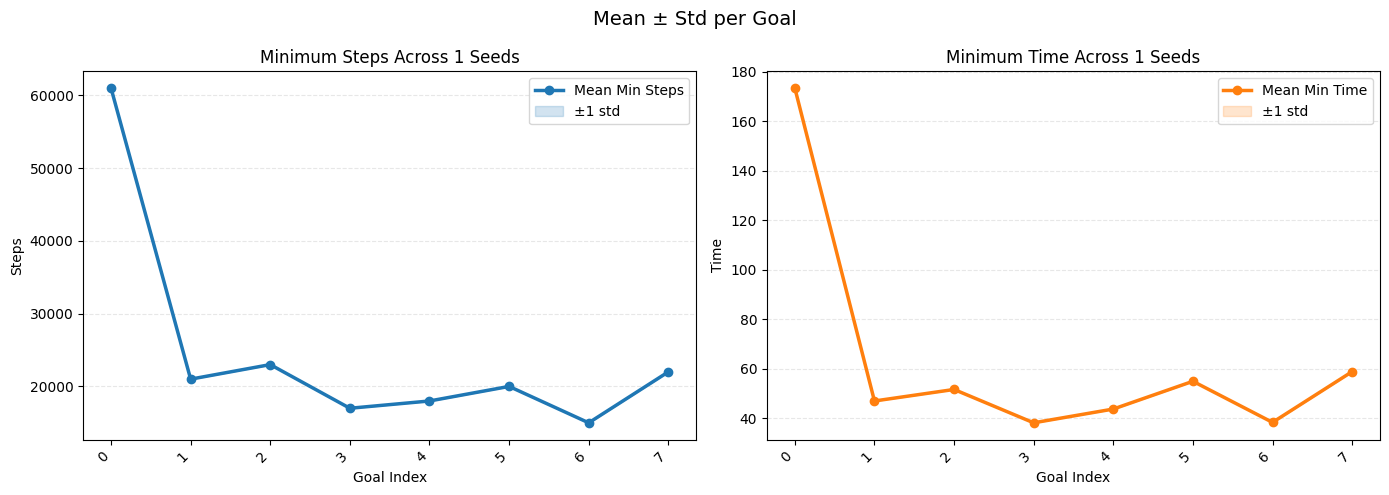

In [4]:
plot_min_steps_and_min_time(overall_results=overall_results, seeds=SEEDS)

In [5]:

# ============================================================
# GENERAL HELPERS
# ============================================================

def to_tensor(x, device=None):
    """
    Converts NumPy arrays or tensors to float32 tensors.
    """
    if isinstance(x, np.ndarray):
        x = torch.from_numpy(x)

    x = x.detach().float()

    if device is not None:
        x = x.to(device)

    return x


def flatten_embeddings(x):
    """
    Converts an embedding tensor to:

        [num_vectors, embedding_dim]

    Examples:
        [52, 4, 64] -> [208, 64]
        [10, 64]    -> [10, 64]
        [64]        -> [1, 64]
    """
    x = to_tensor(x)

    if x.ndim == 1:
        x = x.unsqueeze(0)

    return x.reshape(-1, x.shape[-1])


# ============================================================
# PAIRWISE COSINE DIAGNOSTICS
# ============================================================

@torch.no_grad()
def pairwise_cosine_statistics(
    embeddings,
    name="embedding",
):
    """
    Computes the distribution of pairwise cosine similarities.
    """

    x = flatten_embeddings(embeddings)

    if x.shape[0] < 2:
        print(
            f"{name}: fewer than two vectors; "
            "pairwise statistics unavailable."
        )
        return None

    x = F.normalize(
        x,
        dim=-1,
    )

    cosine_matrix = x @ x.T

    upper_indices = torch.triu_indices(
        cosine_matrix.shape[0],
        cosine_matrix.shape[1],
        offset=1,
        device=cosine_matrix.device,
    )

    values = cosine_matrix[
        upper_indices[0],
        upper_indices[1],
    ]

    result = {
        "name": name,
        "num_vectors": int(x.shape[0]),
        "mean": values.mean().item(),
        "std": values.std(unbiased=False).item(),
        "min": values.min().item(),
        "max": values.max().item(),
        "p05": torch.quantile(
            values,
            0.05,
        ).item(),
        "p50": torch.quantile(
            values,
            0.50,
        ).item(),
        "p95": torch.quantile(
            values,
            0.95,
        ).item(),
    }

    print(
        f"\n========== {name}: PAIRWISE COSINE =========="
    )

    print(
        f"Number of vectors: {result['num_vectors']}"
    )

    print(
        f"Mean: {result['mean']:.6f}"
    )

    print(
        f"Std: {result['std']:.6f}"
    )

    print(
        f"Min: {result['min']:.6f}"
    )

    print(
        f"Max: {result['max']:.6f}"
    )

    print(
        f"P05: {result['p05']:.6f}"
    )

    print(
        f"Median: {result['p50']:.6f}"
    )

    print(
        f"P95: {result['p95']:.6f}"
    )

    return result


# ============================================================
# SPECTRAL DIAGNOSTICS
# ============================================================

@torch.no_grad()
def spectral_diagnostics(
    embeddings,
    name="embedding",
):
    """
    Computes the full singular-value spectrum and
    several effective-dimensionality measures.

    The embedding matrix is centered before SVD.
    """

    x = flatten_embeddings(embeddings)

    if x.shape[0] < 2:
        print(
            f"{name}: fewer than two vectors; "
            "spectral statistics unavailable."
        )
        return None

    x = x - x.mean(
        dim=0,
        keepdim=True,
    )

    singular_values = torch.linalg.svdvals(x)

    variance = singular_values.square()

    total_variance = variance.sum()

    if total_variance <= 1e-12:
        print(
            f"{name}: zero centered variance."
        )
        return None

    explained_variance = (
        variance / total_variance
    )

    cumulative_variance = torch.cumsum(
        explained_variance,
        dim=0,
    )

    effective_rank = torch.exp(
        -torch.sum(
            explained_variance
            * torch.log(
                explained_variance.clamp_min(
                    1e-12
                )
            )
        )
    )

    participation_ratio = (
        variance.sum().square()
        / variance.square().sum().clamp_min(
            1e-12
        )
    )

    stable_rank = (
        variance.sum()
        / variance[0].clamp_min(1e-12)
    )

    result = {
        "name": name,
        "singular_values": (
            singular_values.cpu().numpy()
        ),
        "explained_variance": (
            explained_variance.cpu().numpy()
        ),
        "cumulative_variance": (
            cumulative_variance.cpu().numpy()
        ),
        "effective_rank": (
            effective_rank.item()
        ),
        "participation_ratio": (
            participation_ratio.item()
        ),
        "stable_rank": stable_rank.item(),
    }

    print(
        f"\n========== {name}: SPECTRAL DIAGNOSTICS =========="
    )

    print(
        "Top singular values:",
        np.round(
            result["singular_values"][:10],
            6,
        ),
    )

    print(
        "Cumulative variance:",
        np.round(
            result["cumulative_variance"][:10],
            6,
        ),
    )

    print(
        f"Effective rank: "
        f"{result['effective_rank']:.6f}"
    )

    print(
        f"Participation ratio: "
        f"{result['participation_ratio']:.6f}"
    )

    print(
        f"Stable rank: "
        f"{result['stable_rank']:.6f}"
    )

    return result


# ============================================================
# COMBINED REPRESENTATION DIAGNOSTICS
# ============================================================

def diagnose_representation(
    embeddings,
    name="embedding",
):
    """
    Runs pairwise cosine and spectral diagnostics.
    """

    cosine_result = (
        pairwise_cosine_statistics(
            embeddings,
            name=name,
        )
    )

    spectral_result = (
        spectral_diagnostics(
            embeddings,
            name=name,
        )
    )

    return {
        "cosine": cosine_result,
        "spectral": spectral_result,
    }


# ============================================================
# PHI DIAGNOSTICS
# ============================================================

@torch.no_grad()
def diagnose_phi(
    phi,
    name="phi(s,a)",
):
    """
    Diagnoses phi(s,a).

    Accepts shapes such as:
        [states, actions, dim]
        [num_vectors, dim]
    """

    phi_tensor = to_tensor(phi)

    print(
        f"\n{name} original shape: "
        f"{tuple(phi_tensor.shape)}"
    )

    phi_flat = flatten_embeddings(
        phi_tensor
    )

    norms = torch.linalg.norm(
        phi_flat,
        dim=-1,
    )

    print(
        f"{name} flattened shape: "
        f"{tuple(phi_flat.shape)}"
    )

    print(
        f"{name} norm mean: "
        f"{norms.mean().item():.6f}"
    )

    print(
        f"{name} norm std: "
        f"{norms.std(unbiased=False).item():.6f}"
    )

    representation_result = (
        diagnose_representation(
            phi_flat,
            name=name,
        )
    )

    return {
        "norms": norms.cpu(),
        **representation_result,
    }


# ============================================================
# PSI / TASK-EMBEDDING DIAGNOSTICS
# ============================================================

def diagnose_task_embeddings(
    task_embeddings,
    seed=None,
):
    """
    Diagnoses task embeddings psi(g) for one seed.

    task_embeddings may be:
        list of [64]-dimensional arrays
        array of shape [num_tasks, 64]
    """

    psi = np.asarray(
        task_embeddings,
        dtype=np.float32,
    )

    if psi.ndim == 1:
        psi = psi[None, :]

    name = "psi(g)"

    if seed is not None:
        name += f", seed={seed}"

    print(
        f"\n{name} shape: "
        f"{tuple(psi.shape)}"
    )

    return diagnose_representation(
        psi,
        name=name,
    )


# ============================================================
# PHI-PSI ALIGNMENT
# ============================================================

@torch.no_grad()
def diagnose_phi_psi_alignment(
    phi,
    psi,
    task_label=None,
):
    """
    Computes cosine(phi(s,a), psi(g)).
    """

    phi_flat = flatten_embeddings(phi)
    psi_flat = flatten_embeddings(psi)

    if psi_flat.shape[0] != 1:
        raise ValueError(
            "psi must contain exactly one task vector."
        )

    phi_unit = F.normalize(
        phi_flat,
        dim=-1,
    )

    psi_unit = F.normalize(
        psi_flat,
        dim=-1,
    )

    cosine_values = (
        phi_unit @ psi_unit.T
    ).squeeze(-1)

    print(
        "\n========== PHI-PSI ALIGNMENT =========="
    )

    if task_label is not None:
        print(
            f"Task: {task_label}"
        )

    print(
        f"Mean: "
        f"{cosine_values.mean().item():.6f}"
    )

    print(
        f"Std: "
        f"{cosine_values.std(unbiased=False).item():.6f}"
    )

    print(
        f"Min: "
        f"{cosine_values.min().item():.6f}"
    )

    print(
        f"Max: "
        f"{cosine_values.max().item():.6f}"
    )

    return cosine_values.cpu()


# ============================================================
# Q-VALUE TASK SEPARATION
# ============================================================

@torch.no_grad()
def diagnose_q_task_separation(
    phi,
    psi_tasks,
    task_labels=None,
    normalize_inputs=False,
):
    """
    Computes Q-like values:

        Q(s,a,g) = phi(s,a)^T psi(g)

    phi:
        [states, actions, dim]
        or [num_state_actions, dim]

    psi_tasks:
        [num_tasks, dim]
    """

    phi_flat = flatten_embeddings(phi)
    psi_matrix = flatten_embeddings(
        psi_tasks
    )

    if normalize_inputs:
        phi_flat = F.normalize(
            phi_flat,
            dim=-1,
        )

        psi_matrix = F.normalize(
            psi_matrix,
            dim=-1,
        )

    q_values = phi_flat @ psi_matrix.T

    q_std_across_tasks = q_values.std(
        dim=1,
        unbiased=False,
    )

    q_std_across_state_actions = (
        q_values.std(
            dim=0,
            unbiased=False,
        )
    )

    q_mean_per_task = q_values.mean(
        dim=0
    )

    print(
        "\n========== Q TASK SEPARATION =========="
    )

    print(
        f"Q matrix shape: "
        f"{tuple(q_values.shape)}"
    )

    print(
        "Mean Q std across tasks: "
        f"{q_std_across_tasks.mean().item():.6f}"
    )

    print(
        "Median Q std across tasks: "
        f"{q_std_across_tasks.median().item():.6f}"
    )

    print(
        "Mean Q std across state-actions: "
        f"{q_std_across_state_actions.mean().item():.6f}"
    )

    if task_labels is not None:
        for label, value in zip(
            task_labels,
            q_mean_per_task,
        ):
            print(
                f"{label}: "
                f"mean Q={value.item():.6f}"
            )

    return {
        "q_values": q_values.cpu(),
        "q_std_across_tasks": (
            q_std_across_tasks.cpu()
        ),
        "q_std_across_state_actions": (
            q_std_across_state_actions.cpu()
        ),
        "q_mean_per_task": (
            q_mean_per_task.cpu()
        ),
    }


# ============================================================
# RETRIEVAL DIAGNOSTICS
# ============================================================

def retrieval_weight_diagnostics(
    retrieval_history,
):
    """
    Diagnoses retrieved softmax weights.

    For top-k=3:
        maximum entropy = log(3)
    """

    entropy_values = []
    maximum_weights = []
    similarity_gaps = []

    for record in retrieval_history:

        if not record.get(
            "retrieved",
            False,
        ):
            continue

        weights = np.asarray(
            record.get(
                "weights",
                [],
            ),
            dtype=np.float64,
        )

        similarities = np.asarray(
            record.get(
                "similarities",
                [],
            ),
            dtype=np.float64,
        )

        if weights.size == 0:
            continue

        weights = weights / np.maximum(
            weights.sum(),
            1e-12,
        )

        entropy = -np.sum(
            weights
            * np.log(
                np.maximum(
                    weights,
                    1e-12,
                )
            )
        )

        entropy_values.append(entropy)
        maximum_weights.append(weights.max())

        if similarities.size >= 2:
            sorted_similarities = np.sort(
                similarities
            )[::-1]

            similarity_gaps.append(
                sorted_similarities[0]
                - sorted_similarities[1]
            )

    print(
        "\n========== RETRIEVAL WEIGHT DIAGNOSTICS =========="
    )

    if len(entropy_values) == 0:
        print(
            "No retrieved task records found."
        )
        return None

    entropy_values = np.asarray(
        entropy_values
    )

    maximum_weights = np.asarray(
        maximum_weights
    )

    similarity_gaps = np.asarray(
        similarity_gaps
    )

    print(
        "Mean entropy: "
        f"{entropy_values.mean():.6f}"
    )

    print(
        "Mean maximum weight: "
        f"{maximum_weights.mean():.6f}"
    )

    if similarity_gaps.size > 0:
        print(
            "Mean top-1/top-2 similarity gap: "
            f"{similarity_gaps.mean():.6f}"
        )

    return {
        "entropy": entropy_values,
        "maximum_weight": maximum_weights,
        "similarity_gaps": similarity_gaps,
    }


# ============================================================
# OPTIONAL PRE-NORMALIZATION DIAGNOSTICS
# ============================================================

@torch.no_grad()
def diagnose_pre_normalized_phi(
    phi_pre_norm,
    name="phi before normalization",
):
    """
    Use this only with phi before F.normalize().
    """

    x = flatten_embeddings(
        phi_pre_norm
    )

    norms = x.norm(
        dim=-1
    )

    result = {
        "mean": x.mean().item(),
        "std": x.std(unbiased=False).item(),
        "norm_mean": norms.mean().item(),
        "norm_std": norms.std(
            unbiased=False
        ).item(),
        "near_zero_fraction": (
            x.abs() < 1e-4
        ).float().mean().item(),
    }

    print(
        f"\n========== {name.upper()} =========="
    )

    print(
        f"Mean: {result['mean']:.6f}"
    )

    print(
        f"Std: {result['std']:.6f}"
    )

    print(
        f"Norm mean: {result['norm_mean']:.6f}"
    )

    print(
        f"Norm std: {result['norm_std']:.6f}"
    )

    print(
        "Near-zero fraction: "
        f"{result['near_zero_fraction']:.6f}"
    )

    return result


@torch.no_grad()
def diagnose_tanh_saturation(
    preactivation,
    thresholds=(1.0, 2.0, 3.0),
):
    """
    Use this with the input to tanh, not its output.
    """

    z = to_tensor(
        preactivation
    )

    print(
        "\n========== TANH SATURATION =========="
    )

    result = {}

    for threshold in thresholds:
        fraction = (
            z.abs() > threshold
        ).float().mean().item()

        result[threshold] = fraction

        print(
            f"|preactivation| > {threshold}: "
            f"{fraction:.6f}"
        )

    return result

In [6]:
# ============================================================
# RUN POST-TRAINING DIAGNOSTICS
# ============================================================

all_diagnostics = {
    "task_embeddings": {},
    "retrieval": {},
    "phi": {},
    "q_separation": {},
}


# ============================================================
# DIAGNOSE TASK EMBEDDINGS AND RETRIEVAL PER SEED
# ============================================================

for seed in SEEDS:

    print(
        "\n\n"
        + "=" * 80
    )

    print(
        f"POST-TRAINING DIAGNOSTICS — SEED {seed}"
    )

    print(
        "=" * 80
    )

    if seed not in seed_task_memories:
        print(
            f"No task memory found for seed {seed}."
        )
        continue

    task_memory = seed_task_memories[seed]

    task_embeddings = np.stack(
        [
            np.asarray(
                item["task_embedding"],
                dtype=np.float32,
            ).reshape(-1)
            for item in task_memory
        ],
        axis=0,
    )

    task_labels_for_seed = [
        item.get(
            "task_label",
            f"task_{i}",
        )
        for i, item in enumerate(task_memory)
    ]

    # --------------------------------------------------------
    # psi(g) diagnostics
    # --------------------------------------------------------

    psi_result = diagnose_task_embeddings(
        task_embeddings,
        seed=seed,
    )

    all_diagnostics[
        "task_embeddings"
    ][seed] = psi_result

    # --------------------------------------------------------
    # Retrieval-weight diagnostics
    # --------------------------------------------------------

    retrieval_history = (
        seed_retrieval_histories.get(
            seed,
            [],
        )
    )

    retrieval_result = (
        retrieval_weight_diagnostics(
            retrieval_history
        )
    )

    all_diagnostics[
        "retrieval"
    ][seed] = retrieval_result

    print(
        "\nTask labels:",
        task_labels_for_seed,
    )

    print(
        "Task embedding matrix shape:",
        task_embeddings.shape,
    )


# ============================================================
# OPTIONAL PHI DIAGNOSTICS
# ============================================================

print(
    "\n\n"
    + "=" * 80
)

print(
    "OPTIONAL PHI DIAGNOSTICS"
)

print(
    "=" * 80
)

print(
    "To run phi diagnostics, define phi_by_seed first:"
)

print(
    "phi_by_seed[seed] = phi_tensor"
)

print(
    "Expected shape can be [states, actions, 64] "
    "or [num_vectors, 64]."
)


if "phi_by_seed" in globals():

    for seed, phi_tensor in phi_by_seed.items():

        print(
            "\n"
            + "-" * 80
        )

        print(
            f"PHI DIAGNOSTICS — SEED {seed}"
        )

        phi_result = diagnose_phi(
            phi_tensor,
            name=f"phi(s,a), seed={seed}",
        )

        all_diagnostics[
            "phi"
        ][seed] = phi_result

else:

    print(
        "\nphi_by_seed was not found. "
        "Skipping phi diagnostics."
    )


# ============================================================
# OPTIONAL Q-SEPARATION DIAGNOSTICS
# ============================================================

print(
    "\n\n"
    + "=" * 80
)

print(
    "OPTIONAL Q-SEPARATION DIAGNOSTICS"
)

print(
    "=" * 80
)

print(
    "To run Q-separation diagnostics, define:"
)

print(
    "phi_by_seed[seed] = phi_tensor"
)

print(
    "The task embeddings are automatically taken "
    "from seed_task_memories."
)


if "phi_by_seed" in globals():

    for seed, phi_tensor in phi_by_seed.items():

        if seed not in seed_task_memories:
            continue

        task_memory = seed_task_memories[seed]

        task_embeddings = np.stack(
            [
                np.asarray(
                    item["task_embedding"],
                    dtype=np.float32,
                ).reshape(-1)
                for item in task_memory
            ],
            axis=0,
        )

        task_labels_for_seed = [
            item.get(
                "task_label",
                f"task_{i}",
            )
            for i, item in enumerate(task_memory)
        ]

        q_result = (
            diagnose_q_task_separation(
                phi=phi_tensor,
                psi_tasks=task_embeddings,
                task_labels=task_labels_for_seed,
                normalize_inputs=False,
            )
        )

        all_diagnostics[
            "q_separation"
        ][seed] = q_result


# ============================================================
# OPTIONAL CURRENT-TASK PHI-PSI ALIGNMENT
# ============================================================

print(
    "\n\n"
    + "=" * 80
)

print(
    "OPTIONAL PHI-PSI ALIGNMENT"
)

print(
    "=" * 80
)

print(
    "To run current-task phi-psi alignment, define:"
)

print(
    "phi_current = ...              # [states, actions, 64]"
)

print(
    "psi_current = ...              # [1, 64]"
)

print(
    "current_task_label = 'task_x'"
)

if (
    "phi_current" in globals()
    and "psi_current" in globals()
):

    current_alignment = (
        diagnose_phi_psi_alignment(
            phi=phi_current,
            psi=psi_current,
            task_label=globals().get(
                "current_task_label",
                None,
            ),
        )
    )

    all_diagnostics[
        "current_phi_psi_alignment"
    ] = current_alignment

else:

    print(
        "\nphi_current and psi_current were not found. "
        "Skipping current-task alignment."
    )


print(
    "\n\nDiagnostics complete."
)

print(
    "Results are stored in: all_diagnostics"
)



POST-TRAINING DIAGNOSTICS — SEED 42

psi(g), seed=42 shape: (8, 16)

========== psi(g), seed=42: PAIRWISE COSINE ==========
Number of vectors: 8
Mean: 0.975661
Std: 0.021148
Min: 0.935829
Max: 0.998540
P05: 0.942887
Median: 0.986311
P95: 0.997080

========== psi(g), seed=42: SPECTRAL DIAGNOSTICS ==========
Top singular values: [0.353572 0.151345 0.116064 0.073039 0.043236 0.038522 0.017266 0.      ]
Cumulative variance: [0.733752 0.868192 0.947257 0.978569 0.98954  0.99825  1.       1.      ]
Effective rank: 2.479217
Participation ratio: 1.773372
Stable rank: 1.362858

========== RETRIEVAL WEIGHT DIAGNOSTICS ==========
Mean entropy: 0.321661
Mean maximum weight: 0.838692
Mean top-1/top-2 similarity gap: 1.107706

Task labels: ['task_0', 'task_1', 'task_2', 'task_3', 'task_4', 'task_5', 'task_6', 'task_7']
Task embedding matrix shape: (8, 16)


OPTIONAL PHI DIAGNOSTICS
To run phi diagnostics, define phi_by_seed first:
phi_by_seed[seed] = phi_tensor
Expected shape can be [states, actio


========== PER-SEED DATASET SIZES ==========
seed=42 | n_tasks=8

========== PER-SEED DISTANCE CORRELATION ==========
seed=42 | rho=0.8475 | p=1.2668e-08

========== PER-SEED NEIGHBOUR AGREEMENT ==========
seed=42 | top-3 overlap=0.8750

========== AGGREGATE ACROSS SEEDS ==========
Mean per-seed Spearman rho: 0.8475 +/- 0.0000
Median per-seed Spearman rho: 0.8475
Mean per-seed top-k overlap: 0.8750 +/- 0.0000
Median per-seed top-k overlap: 0.8750


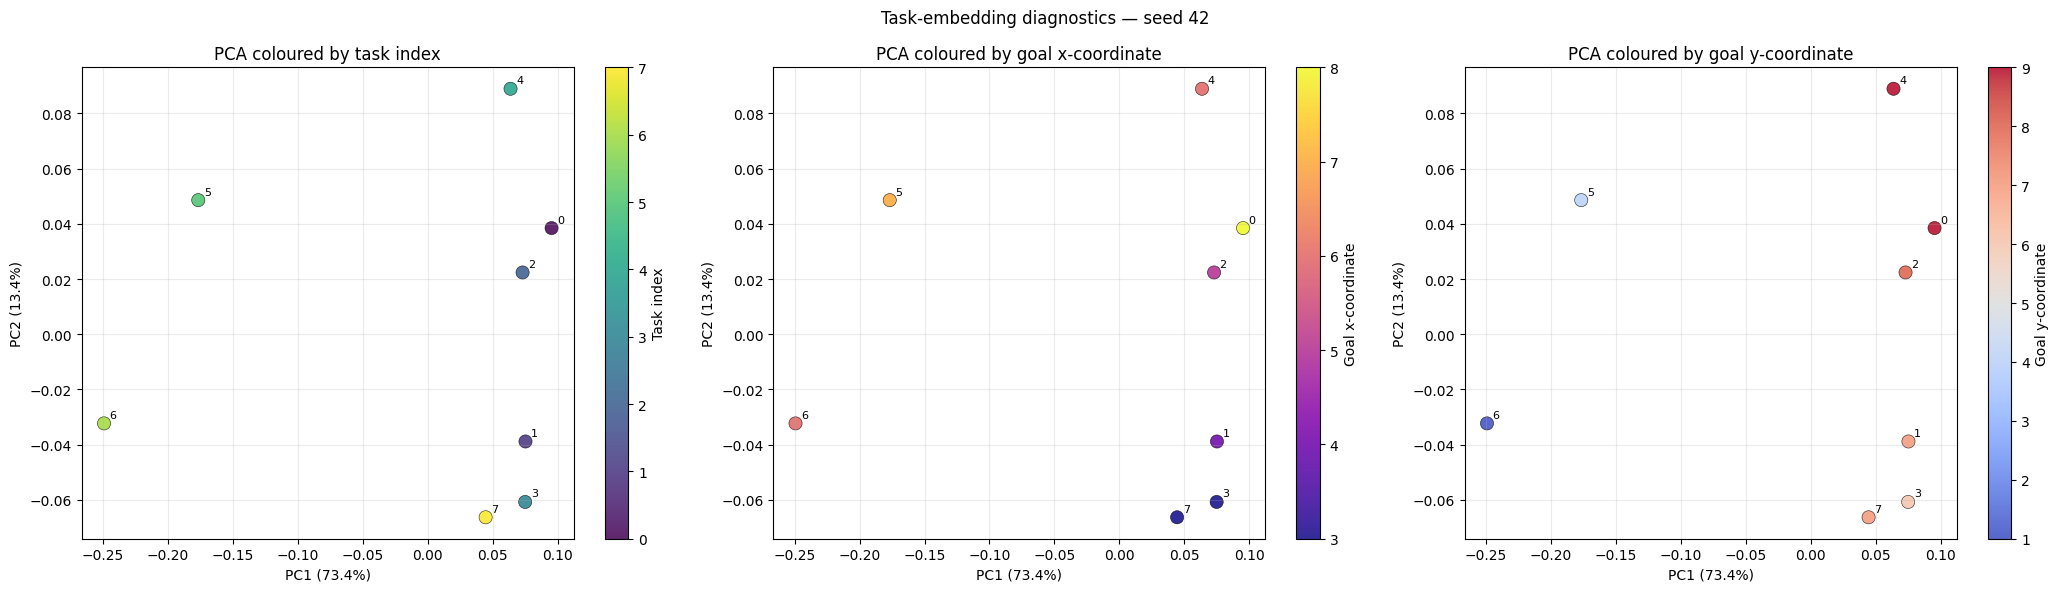

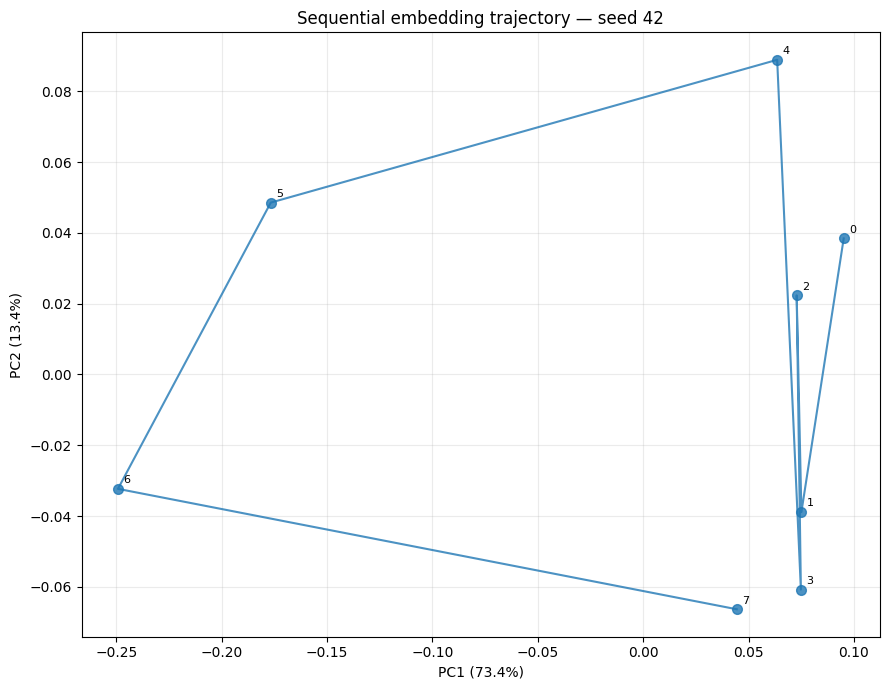

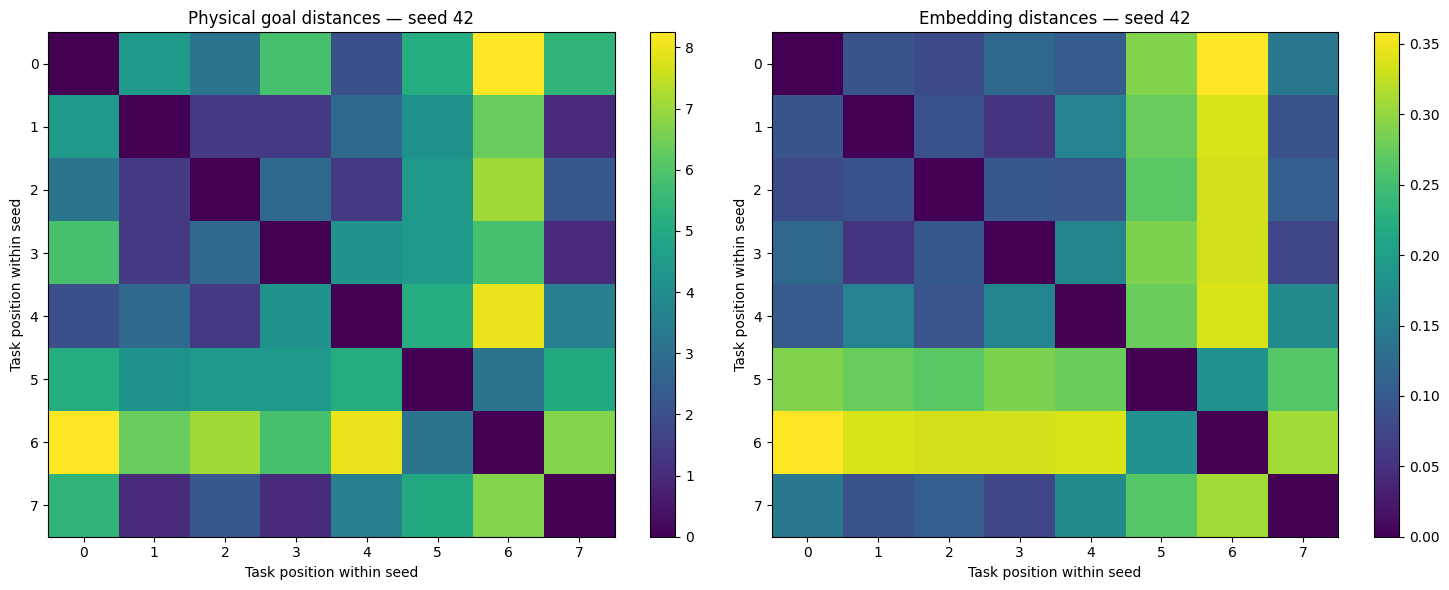

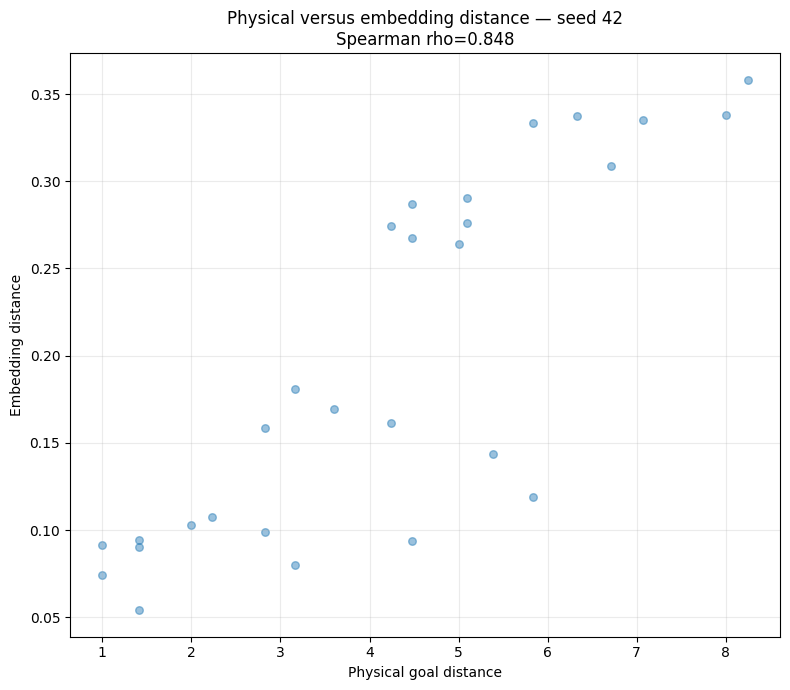


per_seed_summary is available for downstream analysis.


In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from scipy.stats import spearmanr


# ============================================================
# CONFIGURATION
# ============================================================

TOP_K = 3
NORMALIZE_EMBEDDINGS = True
PLOT_PER_SEED = True
ANNOTATE_TASK_INDICES = True


# ============================================================
# VALIDATE INPUT
# ============================================================

if "seed_task_memories" not in globals():
    raise RuntimeError(
        "seed_task_memories was not found. "
        "Run the sequential training loop first."
    )

if len(seed_task_memories) == 0:
    raise RuntimeError("seed_task_memories is empty.")


# ============================================================
# EXTRACT RECORDS, GROUPED BY SEED
# ============================================================

records_by_seed = {}

for seed, task_memory in seed_task_memories.items():

    if task_memory is None:
        continue

    seed_records = []

    for local_idx, item in enumerate(task_memory):

        if "task_embedding" not in item:
            raise KeyError(
                "Each task-memory item must contain "
                "'task_embedding'."
            )

        if "raw_task" not in item:
            raise KeyError(
                "Each task-memory item must contain "
                "'raw_task'."
            )

        task_idx = int(
            item.get(
                "task_idx",
                local_idx,
            )
        )

        seed_records.append(
            {
                "seed": seed,
                "task_idx": task_idx,
                "task_label": item.get(
                    "task_label",
                    f"task_{task_idx}",
                ),
                "goal": np.asarray(
                    item["raw_task"],
                    dtype=np.float32,
                ).reshape(-1),
                "embedding": np.asarray(
                    item["task_embedding"],
                    dtype=np.float32,
                ).reshape(-1),
            }
        )

    if len(seed_records) > 0:
        records_by_seed[seed] = sorted(
            seed_records,
            key=lambda row: row["task_idx"],
        )


if len(records_by_seed) == 0:
    raise RuntimeError(
        "No task embeddings were found."
    )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_rows(matrix):
    norms = np.linalg.norm(
        matrix,
        axis=1,
        keepdims=True,
    )

    return matrix / np.maximum(norms, 1e-8)


def get_nearest_neighbours(
    distance_matrix,
    k,
):
    n = distance_matrix.shape[0]
    k = min(k, n - 1)

    neighbours = []

    for i in range(n):

        row = distance_matrix[i].copy()
        row[i] = np.inf

        nearest = np.argsort(row)[:k]
        neighbours.append(nearest)

    return neighbours


def compute_neighbour_overlap(
    distance_a,
    distance_b,
    k,
):
    k = min(
        k,
        distance_a.shape[0] - 1,
    )

    neighbours_a = get_nearest_neighbours(
        distance_a,
        k,
    )

    neighbours_b = get_nearest_neighbours(
        distance_b,
        k,
    )

    overlaps = []

    for nn_a, nn_b in zip(
        neighbours_a,
        neighbours_b,
    ):
        set_a = set(nn_a.tolist())
        set_b = set(nn_b.tolist())

        overlap = len(
            set_a.intersection(set_b)
        ) / float(k)

        overlaps.append(overlap)

    return float(np.mean(overlaps))


def compute_seed_analysis(
    seed,
    records,
):
    goals = np.stack(
        [
            row["goal"]
            for row in records
        ],
        axis=0,
    )

    embeddings = np.stack(
        [
            row["embedding"]
            for row in records
        ],
        axis=0,
    )

    task_indices = np.asarray(
        [
            row["task_idx"]
            for row in records
        ]
    )

    task_labels = [
        row["task_label"]
        for row in records
    ]

    if NORMALIZE_EMBEDDINGS:
        embeddings_for_analysis = normalize_rows(
            embeddings
        )
    else:
        embeddings_for_analysis = embeddings.copy()

    n_tasks = len(records)

    result = {
        "seed": seed,
        "n_tasks": n_tasks,
        "goals": goals,
        "embeddings": embeddings,
        "embeddings_for_analysis": (
            embeddings_for_analysis
        ),
        "task_indices": task_indices,
        "task_labels": task_labels,
    }

    if n_tasks < 3:
        result.update(
            {
                "physical_distances": None,
                "embedding_distances": None,
                "embedding_cosine_distances": None,
                "spearman_rho": np.nan,
                "spearman_p_value": np.nan,
                "neighbour_overlap": np.nan,
                "effective_top_k": 0,
                "pca": None,
                "embedding_pca": None,
            }
        )

        return result

    # Distances are computed only between tasks from this seed.
    physical_distances = pairwise_distances(
        goals,
        metric="euclidean",
    )

    embedding_distances = pairwise_distances(
        embeddings_for_analysis,
        metric="euclidean",
    )

    embedding_cosine_distances = pairwise_distances(
        embeddings_for_analysis,
        metric="cosine",
    )

    upper_indices = np.triu_indices_from(
        physical_distances,
        k=1,
    )

    physical_values = physical_distances[
        upper_indices
    ]

    embedding_values = embedding_distances[
        upper_indices
    ]

    if (
        np.ptp(physical_values) == 0
        or np.ptp(embedding_values) == 0
    ):
        spearman_rho = np.nan
        spearman_p_value = np.nan
    else:
        spearman_result = spearmanr(
            physical_values,
            embedding_values,
        )

        spearman_rho = float(
            spearman_result.statistic
        )

        spearman_p_value = float(
            spearman_result.pvalue
        )

    effective_top_k = min(
        TOP_K,
        n_tasks - 1,
    )

    neighbour_overlap = compute_neighbour_overlap(
        physical_distances,
        embedding_distances,
        effective_top_k,
    )

    # PCA is fitted independently for each seed.
    n_components = min(
        2,
        n_tasks,
        embeddings_for_analysis.shape[1],
    )

    pca = PCA(
        n_components=n_components,
        random_state=0,
    )

    embedding_pca = pca.fit_transform(
        embeddings_for_analysis
    )

    if n_components == 1:
        embedding_pca = np.column_stack(
            [
                embedding_pca[:, 0],
                np.zeros(n_tasks),
            ]
        )

    result.update(
        {
            "physical_distances": (
                physical_distances
            ),
            "embedding_distances": (
                embedding_distances
            ),
            "embedding_cosine_distances": (
                embedding_cosine_distances
            ),
            "spearman_rho": spearman_rho,
            "spearman_p_value": spearman_p_value,
            "neighbour_overlap": (
                neighbour_overlap
            ),
            "effective_top_k": effective_top_k,
            "pca": pca,
            "embedding_pca": embedding_pca,
        }
    )

    return result


# ============================================================
# COMPUTE ANALYSIS INDEPENDENTLY PER SEED
# ============================================================

seed_results = {}

for seed, records in records_by_seed.items():

    seed_results[seed] = compute_seed_analysis(
        seed,
        records,
    )


# ============================================================
# PRINT PER-SEED METRICS
# ============================================================

print(
    "\n========== PER-SEED DATASET SIZES =========="
)

for seed, result in seed_results.items():
    print(
        f"seed={seed} | "
        f"n_tasks={result['n_tasks']}"
    )


print(
    "\n========== PER-SEED DISTANCE CORRELATION =========="
)

for seed, result in seed_results.items():
    print(
        f"seed={seed} | "
        f"rho={result['spearman_rho']:.4f} | "
        f"p={result['spearman_p_value']:.4e}"
    )


print(
    "\n========== PER-SEED NEIGHBOUR AGREEMENT =========="
)

for seed, result in seed_results.items():
    print(
        f"seed={seed} | "
        f"top-{result['effective_top_k']} "
        f"overlap="
        f"{result['neighbour_overlap']:.4f}"
    )


# ============================================================
# AGGREGATE ONLY PER-SEED METRICS
# ============================================================

valid_results = [
    result
    for result in seed_results.values()
    if result["n_tasks"] >= 3
]

if len(valid_results) > 0:

    rhos = np.asarray(
        [
            result["spearman_rho"]
            for result in valid_results
        ]
    )

    overlaps = np.asarray(
        [
            result["neighbour_overlap"]
            for result in valid_results
        ]
    )

    print(
        "\n========== AGGREGATE ACROSS SEEDS =========="
    )

    print(
        "Mean per-seed Spearman rho: "
        f"{np.nanmean(rhos):.4f} "
        f"+/- {np.nanstd(rhos):.4f}"
    )

    print(
        "Median per-seed Spearman rho: "
        f"{np.nanmedian(rhos):.4f}"
    )

    print(
        "Mean per-seed top-k overlap: "
        f"{np.nanmean(overlaps):.4f} "
        f"+/- {np.nanstd(overlaps):.4f}"
    )

    print(
        "Median per-seed top-k overlap: "
        f"{np.nanmedian(overlaps):.4f}"
    )


# ============================================================
# PER-SEED PLOTS
# ============================================================

if PLOT_PER_SEED:

    for seed, result in seed_results.items():

        if result["n_tasks"] < 3:
            continue

        pca = result["pca"]
        embedding_pca = result["embedding_pca"]
        goals = result["goals"]
        task_indices = result["task_indices"]

        pc1_variance = (
            pca.explained_variance_ratio_[0]
            * 100.0
        )

        if len(
            pca.explained_variance_ratio_
        ) > 1:
            pc2_variance = (
                pca.explained_variance_ratio_[1]
                * 100.0
            )
        else:
            pc2_variance = 0.0

        # ----------------------------------------------------
        # PCA coloured by task index and goal coordinates
        # ----------------------------------------------------

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(21, 6),
        )

        fig.suptitle(
            f"Task-embedding diagnostics — seed {seed}"
        )

        scatter_1 = axes[0].scatter(
            embedding_pca[:, 0],
            embedding_pca[:, 1],
            c=task_indices,
            cmap="viridis",
            s=90,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.4,
        )

        axes[0].set_title(
            "PCA coloured by task index"
        )

        axes[0].set_xlabel(
            f"PC1 ({pc1_variance:.1f}%)"
        )

        axes[0].set_ylabel(
            f"PC2 ({pc2_variance:.1f}%)"
        )

        fig.colorbar(
            scatter_1,
            ax=axes[0],
            label="Task index",
        )

        scatter_2 = axes[1].scatter(
            embedding_pca[:, 0],
            embedding_pca[:, 1],
            c=goals[:, 0],
            cmap="plasma",
            s=90,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.4,
        )

        axes[1].set_title(
            "PCA coloured by goal x-coordinate"
        )

        axes[1].set_xlabel(
            f"PC1 ({pc1_variance:.1f}%)"
        )

        axes[1].set_ylabel(
            f"PC2 ({pc2_variance:.1f}%)"
        )

        fig.colorbar(
            scatter_2,
            ax=axes[1],
            label="Goal x-coordinate",
        )

        scatter_3 = axes[2].scatter(
            embedding_pca[:, 0],
            embedding_pca[:, 1],
            c=goals[:, 1],
            cmap="coolwarm",
            s=90,
            alpha=0.85,
            edgecolors="black",
            linewidths=0.4,
        )

        axes[2].set_title(
            "PCA coloured by goal y-coordinate"
        )

        axes[2].set_xlabel(
            f"PC1 ({pc1_variance:.1f}%)"
        )

        axes[2].set_ylabel(
            f"PC2 ({pc2_variance:.1f}%)"
        )

        fig.colorbar(
            scatter_3,
            ax=axes[2],
            label="Goal y-coordinate",
        )

        if ANNOTATE_TASK_INDICES:

            for i, task_idx in enumerate(
                task_indices
            ):

                for ax in axes:
                    ax.annotate(
                        str(task_idx),
                        (
                            embedding_pca[i, 0],
                            embedding_pca[i, 1],
                        ),
                        xytext=(4, 4),
                        textcoords="offset points",
                        fontsize=8,
                    )

        for ax in axes:
            ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # Sequential trajectory
        # ----------------------------------------------------

        fig, ax = plt.subplots(
            figsize=(9, 7)
        )

        ax.plot(
            embedding_pca[:, 0],
            embedding_pca[:, 1],
            "-o",
            alpha=0.8,
            linewidth=1.5,
            markersize=7,
        )

        for i, task_idx in enumerate(
            task_indices
        ):
            ax.annotate(
                str(task_idx),
                (
                    embedding_pca[i, 0],
                    embedding_pca[i, 1],
                ),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
            )

        ax.set_title(
            f"Sequential embedding trajectory — seed {seed}"
        )

        ax.set_xlabel(
            f"PC1 ({pc1_variance:.1f}%)"
        )

        ax.set_ylabel(
            f"PC2 ({pc2_variance:.1f}%)"
        )

        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # Per-seed distance matrices
        # ----------------------------------------------------

        fig, axes = plt.subplots(
            1,
            2,
            figsize=(15, 6),
        )

        image_1 = axes[0].imshow(
            result["physical_distances"],
            cmap="viridis",
            aspect="auto",
        )

        axes[0].set_title(
            f"Physical goal distances — seed {seed}"
        )

        axes[0].set_xlabel(
            "Task position within seed"
        )

        axes[0].set_ylabel(
            "Task position within seed"
        )

        fig.colorbar(
            image_1,
            ax=axes[0],
        )

        image_2 = axes[1].imshow(
            result["embedding_distances"],
            cmap="viridis",
            aspect="auto",
        )

        axes[1].set_title(
            f"Embedding distances — seed {seed}"
        )

        axes[1].set_xlabel(
            "Task position within seed"
        )

        axes[1].set_ylabel(
            "Task position within seed"
        )

        fig.colorbar(
            image_2,
            ax=axes[1],
        )

        plt.tight_layout()
        plt.show()

        # ----------------------------------------------------
        # Physical distance versus embedding distance
        # ----------------------------------------------------

        upper_indices = np.triu_indices_from(
            result["physical_distances"],
            k=1,
        )

        physical_values = result[
            "physical_distances"
        ][upper_indices]

        embedding_values = result[
            "embedding_distances"
        ][upper_indices]

        fig, ax = plt.subplots(
            figsize=(8, 7)
        )

        ax.scatter(
            physical_values,
            embedding_values,
            s=30,
            alpha=0.45,
        )

        ax.set_title(
            f"Physical versus embedding distance — seed {seed}\n"
            f"Spearman rho="
            f"{result['spearman_rho']:.3f}"
        )

        ax.set_xlabel(
            "Physical goal distance"
        )

        ax.set_ylabel(
            "Embedding distance"
        )

        ax.grid(alpha=0.25)

        plt.tight_layout()
        plt.show()


# ============================================================
# SUMMARY TABLE
# ============================================================

per_seed_summary = [
    {
        "seed": seed,
        "n_tasks": result["n_tasks"],
        "spearman_rho": result["spearman_rho"],
        "spearman_p_value": (
            result["spearman_p_value"]
        ),
        "neighbour_overlap": (
            result["neighbour_overlap"]
        ),
        "effective_top_k": (
            result["effective_top_k"]
        ),
    }
    for seed, result in seed_results.items()
]

print(
    "\nper_seed_summary is available "
    "for downstream analysis."
)

## Backward Compatibility test (or new goal test)

Do not retrain anything, just give the task embedding, and check whether the sa encoder can give good Q functions still. The task embedding must be previously learned.

In [8]:
def evaluate_zero_shot_goal(
    q_network,
    goal,
    make_env,
    device,
    episodes=8,
):
    q_network.eval()

    eval_env = make_env(goal=goal)

    goal_arr = np.asarray(
        goal,
        dtype=np.float32,
    )

    goal_t = torch.tensor(
        goal_arr,
        dtype=torch.float32,
        device=device,
    ).unsqueeze(0)

    def eval_policy(obs):
        obs_t = torch.tensor(
            obs,
            dtype=torch.float32,
            device=device,
        ).unsqueeze(0)

        with torch.inference_mode():
            q_values = q_network.q_val_for_argmax_action(
                obs_t,
                goal_t,
            )

        return int(
            q_values.argmax(
                dim=-1,
            ).item()
        )

    mean_return, mean_length = evaluate_policy(
        eval_env,
        eval_policy,
        episodes=episodes,
    )

    eval_env.close()

    return mean_return, mean_length


# Check that seed-specific goals were saved
if "goals_by_seed" not in globals():
    raise RuntimeError(
        "goals_by_seed does not exist. "
        "Add goals_by_seed = {} before the training loop and "
        "goals_by_seed[seed] = list(GOALS) after sampling goals."
    )


# Store zero-shot results using task_idx rather than goal coordinates
zero_shot_returns = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}

zero_shot_lengths = {
    seed: {
        task_idx: None
        for task_idx in range(NUM_GOALS)
    }
    for seed in SEEDS
}


# Evaluate each final network on the goals sampled for its own seed
for seed in SEEDS:
    print(
        f"\n========== ZERO-SHOT EVALUATION "
        f"SEED {seed} ==========\n"
    )

    q_final = final_q_networks[seed]

    # These are the goals generated for this particular seed
    seed_goals = goals_by_seed[seed]

    if len(seed_goals) != NUM_GOALS:
        raise ValueError(
            f"Seed {seed} has {len(seed_goals)} goals, "
            f"but NUM_GOALS={NUM_GOALS}."
        )

    for task_idx, test_goal in enumerate(seed_goals):
        mean_return, mean_length = evaluate_zero_shot_goal(
            q_network=q_final,
            goal=test_goal,
            make_env=make_env,
            device=DEVICE,
            episodes=8,
        )

        zero_shot_returns[seed][task_idx] = mean_return
        zero_shot_lengths[seed][task_idx] = mean_length

        print(
            f"task_idx={task_idx} | "
            f"goal={test_goal} | "
            f"return={mean_return:.3f} | "
            f"length={mean_length:.1f}"
        )


# Aggregate zero-shot results across seeds by task index
zero_shot_return_mean = {}
zero_shot_return_std = {}
zero_shot_length_mean = {}
zero_shot_length_std = {}

for task_idx in range(NUM_GOALS):
    return_values = [
        zero_shot_returns[seed][task_idx]
        for seed in SEEDS
    ]

    length_values = [
        zero_shot_lengths[seed][task_idx]
        for seed in SEEDS
    ]

    zero_shot_return_mean[task_idx] = float(
        np.mean(return_values)
    )

    zero_shot_return_std[task_idx] = float(
        np.std(return_values)
    )

    zero_shot_length_mean[task_idx] = float(
        np.mean(length_values)
    )

    zero_shot_length_std[task_idx] = float(
        np.std(length_values)
    )


# Print final task-index-based results
print(
    "\n========== FINAL ZERO-SHOT RESULTS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(NUM_GOALS):
    print(
        f"task_idx={task_idx} | "
        f"return="
        f"{zero_shot_return_mean[task_idx]:.3f} "
        f"+/- "
        f"{zero_shot_return_std[task_idx]:.3f} | "
        f"length="
        f"{zero_shot_length_mean[task_idx]:.1f} "
        f"+/- "
        f"{zero_shot_length_std[task_idx]:.1f}"
    )


# Optional diagnostic: show which physical goal each task_idx represented
print(
    "\n========== TASK INDEX TO GOAL MAPPING ==========\n"
)

for task_idx in range(NUM_GOALS):
    task_goal_mapping = {
        seed: goals_by_seed[seed][task_idx]
        for seed in SEEDS
    }

    print(
        f"task_idx={task_idx} | "
        f"goals_by_seed={task_goal_mapping}"
    )


========== ZERO-SHOT EVALUATION SEED 42 ==========

task_idx=0 | goal=(8, 9) | return=0.250 | length=375.8
task_idx=1 | goal=(4, 7) | return=0.625 | length=192.4
task_idx=2 | goal=(5, 8) | return=0.375 | length=315.1
task_idx=3 | goal=(3, 6) | return=1.000 | length=7.1
task_idx=4 | goal=(6, 9) | return=0.125 | length=438.1
task_idx=5 | goal=(7, 4) | return=0.000 | length=500.0
task_idx=6 | goal=(6, 1) | return=0.000 | length=500.0
task_idx=7 | goal=(3, 7) | return=1.000 | length=6.0

========== FINAL ZERO-SHOT RESULTS BY TASK INDEX ==========

task_idx=0 | return=0.250 +/- 0.000 | length=375.8 +/- 0.0
task_idx=1 | return=0.625 +/- 0.000 | length=192.4 +/- 0.0
task_idx=2 | return=0.375 +/- 0.000 | length=315.1 +/- 0.0
task_idx=3 | return=1.000 +/- 0.000 | length=7.1 +/- 0.0
task_idx=4 | return=0.125 +/- 0.000 | length=438.1 +/- 0.0
task_idx=5 | return=0.000 +/- 0.000 | length=500.0 +/- 0.0
task_idx=6 | return=0.000 +/- 0.000 | length=500.0 +/- 0.0
task_idx=7 | return=1.000 +/- 0.000 | 

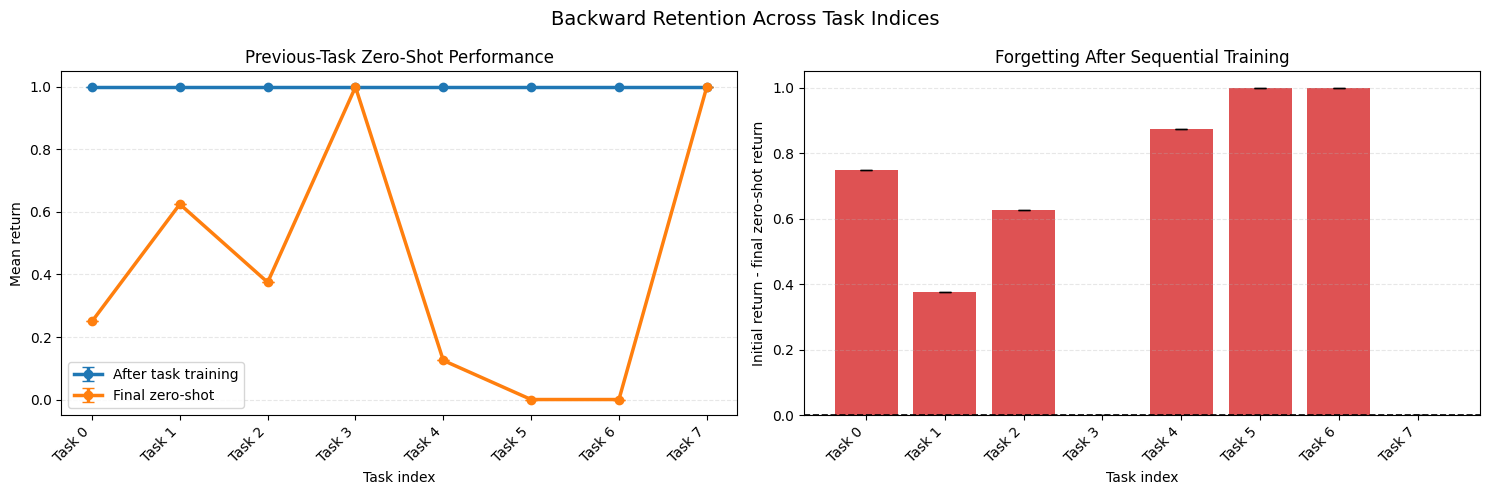

In [9]:
# Logical task labels for plotting
task_labels = [
    f"Task {task_idx}"
    for task_idx in range(NUM_GOALS)
]

task_indices = np.arange(NUM_GOALS)


def get_last_eval_return(eval_history):
    """
    Extract the final return from an evaluation history.

    Handles histories containing:
    - scalar returns
    - (time, return) pairs
    - lists or numpy arrays
    """
    if len(eval_history) == 0:
        return np.nan

    last_value = eval_history[-1]

    if isinstance(
        last_value,
        (tuple, list, np.ndarray),
    ):
        return float(last_value[1])

    return float(last_value)


# ------------------------------------------------------------
# Initial performance after training each task
# ------------------------------------------------------------
initial_returns_by_seed = {
    seed: {}
    for seed in SEEDS
}


for seed_idx, seed in enumerate(SEEDS):
    for task_idx in range(NUM_GOALS):
        eval_history = (
            overall_results[task_idx][
                "eval_returns"
            ][seed_idx]
        )

        initial_returns_by_seed[seed][task_idx] = (
            get_last_eval_return(eval_history)
        )


# ------------------------------------------------------------
# Aggregate initial performance, final zero-shot
# performance, and forgetting by task index
# ------------------------------------------------------------
initial_return_mean = []
initial_return_std = []

final_return_mean = []
final_return_std = []

forgetting_mean = []
forgetting_std = []


for task_idx in range(NUM_GOALS):
    initial_values = [
        initial_returns_by_seed[seed][task_idx]
        for seed in SEEDS
    ]

    final_values = [
        zero_shot_returns[seed][task_idx]
        for seed in SEEDS
    ]

    forgetting_values = [
        initial_returns_by_seed[seed][task_idx]
        - zero_shot_returns[seed][task_idx]
        for seed in SEEDS
    ]

    initial_return_mean.append(
        np.nanmean(initial_values)
    )

    initial_return_std.append(
        np.nanstd(initial_values)
    )

    final_return_mean.append(
        np.nanmean(final_values)
    )

    final_return_std.append(
        np.nanstd(final_values)
    )

    forgetting_mean.append(
        np.nanmean(forgetting_values)
    )

    forgetting_std.append(
        np.nanstd(forgetting_values)
    )


initial_return_mean = np.asarray(
    initial_return_mean
)

initial_return_std = np.asarray(
    initial_return_std
)

final_return_mean = np.asarray(
    final_return_mean
)

final_return_std = np.asarray(
    final_return_std
)

forgetting_mean = np.asarray(
    forgetting_mean
)

forgetting_std = np.asarray(
    forgetting_std
)


# ------------------------------------------------------------
# Plot results
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot performance
# ------------------------------------------------------------
axes[0].errorbar(
    task_indices,
    initial_return_mean,
    yerr=initial_return_std,
    marker="o",
    linewidth=2.5,
    capsize=4,
    color="tab:blue",
    label="After task training",
)

axes[0].errorbar(
    task_indices,
    final_return_mean,
    yerr=final_return_std,
    marker="o",
    linewidth=2.5,
    capsize=4,
    color="tab:orange",
    label="Final zero-shot",
)

axes[0].set_title(
    "Previous-Task Zero-Shot Performance"
)

axes[0].set_xlabel(
    "Task index"
)

axes[0].set_ylabel(
    "Mean return"
)

axes[0].set_xticks(
    task_indices
)

axes[0].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting / backward transfer
# ------------------------------------------------------------
colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    task_indices,
    forgetting_mean,
    yerr=forgetting_std,
    capsize=4,
    color=colors,
    alpha=0.8,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1.2,
)

axes[1].set_title(
    "Forgetting After Sequential Training"
)

axes[1].set_xlabel(
    "Task index"
)

axes[1].set_ylabel(
    "Initial return - final zero-shot return"
)

axes[1].set_xticks(
    task_indices
)

axes[1].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


fig.suptitle(
    "Backward Retention Across Task Indices",
    fontsize=14,
)

fig.tight_layout()

plt.show()


========== CONTINUAL LEARNING METRICS BY TASK INDEX ==========

Task 0 | initial=1.000 +/- 0.000 | final zero-shot=0.250 +/- 0.000 | forgetting=0.750 +/- 0.000 | BWT=-0.750 +/- 0.000 | retention=0.250 +/- 0.000
Task 1 | initial=1.000 +/- 0.000 | final zero-shot=0.625 +/- 0.000 | forgetting=0.375 +/- 0.000 | BWT=-0.375 +/- 0.000 | retention=0.625 +/- 0.000
Task 2 | initial=1.000 +/- 0.000 | final zero-shot=0.375 +/- 0.000 | forgetting=0.625 +/- 0.000 | BWT=-0.625 +/- 0.000 | retention=0.375 +/- 0.000
Task 3 | initial=1.000 +/- 0.000 | final zero-shot=1.000 +/- 0.000 | forgetting=0.000 +/- 0.000 | BWT=0.000 +/- 0.000 | retention=1.000 +/- 0.000
Task 4 | initial=1.000 +/- 0.000 | final zero-shot=0.125 +/- 0.000 | forgetting=0.875 +/- 0.000 | BWT=-0.875 +/- 0.000 | retention=0.125 +/- 0.000
Task 5 | initial=1.000 +/- 0.000 | final zero-shot=0.000 +/- 0.000 | forgetting=1.000 +/- 0.000 | BWT=-1.000 +/- 0.000 | retention=0.000 +/- 0.000
Task 6 | initial=1.000 +/- 0.000 | final zero-shot=0.0

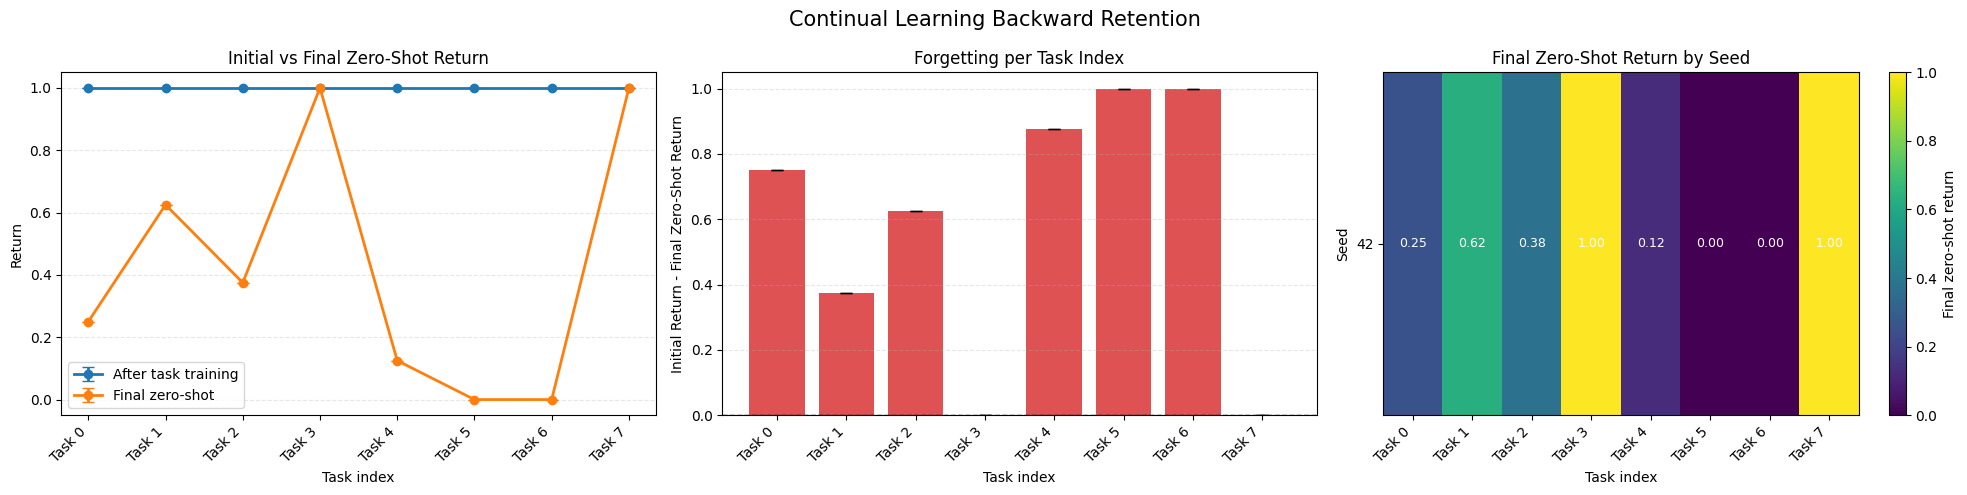

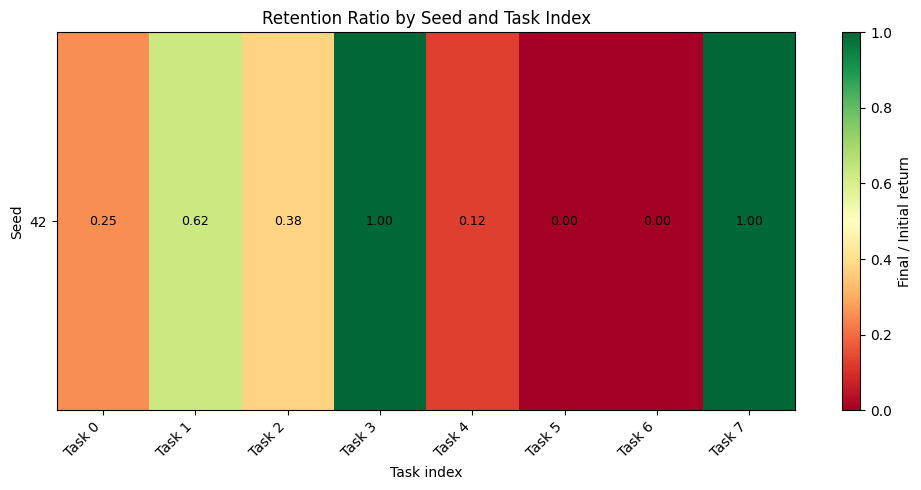

In [10]:
def extract_initial_return(eval_history):
    if len(eval_history) == 0:
        return np.nan

    last_entry = eval_history[-1]

    if isinstance(
        last_entry,
        (tuple, list, np.ndarray),
    ):
        return float(last_entry[1])

    return float(last_entry)


num_seeds = len(SEEDS)
num_tasks = NUM_GOALS


# ------------------------------------------------------------
# Allocate matrices
# Rows    = seeds
# Columns = task indices
# ------------------------------------------------------------
initial_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

final_zero_shot_matrix = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)


# ------------------------------------------------------------
# Fill initial and final zero-shot matrices
# ------------------------------------------------------------
for seed_idx, seed in enumerate(SEEDS):
    for task_idx in range(num_tasks):

        # Initial return after training this task.
        # Results were appended in SEEDS order during training.
        eval_history = (
            overall_results[task_idx][
                "eval_returns"
            ][seed_idx]
        )

        initial_matrix[
            seed_idx,
            task_idx,
        ] = extract_initial_return(
            eval_history
        )

        # Final zero-shot return for this seed/task pair
        final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ] = zero_shot_returns[
            seed
        ][
            task_idx
        ]


# ------------------------------------------------------------
# Continual-learning metrics
# ------------------------------------------------------------
forgetting_matrix = (
    initial_matrix
    - final_zero_shot_matrix
)

backward_transfer_matrix = (
    final_zero_shot_matrix
    - initial_matrix
)


# Use a safe division operation for retention.
# This avoids division by zero when the initial return is zero.
retention_matrix = np.divide(
    final_zero_shot_matrix,
    initial_matrix,
    out=np.full_like(
        final_zero_shot_matrix,
        np.nan,
    ),
    where=np.abs(initial_matrix) > 1e-8,
)


# ------------------------------------------------------------
# Aggregate metrics across seeds
# ------------------------------------------------------------
initial_mean = np.nanmean(
    initial_matrix,
    axis=0,
)

initial_std = np.nanstd(
    initial_matrix,
    axis=0,
)

final_mean = np.nanmean(
    final_zero_shot_matrix,
    axis=0,
)

final_std = np.nanstd(
    final_zero_shot_matrix,
    axis=0,
)

forgetting_mean = np.nanmean(
    forgetting_matrix,
    axis=0,
)

forgetting_std = np.nanstd(
    forgetting_matrix,
    axis=0,
)

bwt_mean = np.nanmean(
    backward_transfer_matrix,
    axis=0,
)

bwt_std = np.nanstd(
    backward_transfer_matrix,
    axis=0,
)

retention_mean = np.nanmean(
    retention_matrix,
    axis=0,
)

retention_std = np.nanstd(
    retention_matrix,
    axis=0,
)


# ------------------------------------------------------------
# Print per-task metrics
# ------------------------------------------------------------
print(
    "\n========== CONTINUAL LEARNING METRICS "
    "BY TASK INDEX ==========\n"
)

for task_idx in range(num_tasks):
    print(
        f"Task {task_idx} | "
        f"initial="
        f"{initial_mean[task_idx]:.3f} "
        f"+/- "
        f"{initial_std[task_idx]:.3f} | "
        f"final zero-shot="
        f"{final_mean[task_idx]:.3f} "
        f"+/- "
        f"{final_std[task_idx]:.3f} | "
        f"forgetting="
        f"{forgetting_mean[task_idx]:.3f} "
        f"+/- "
        f"{forgetting_std[task_idx]:.3f} | "
        f"BWT="
        f"{bwt_mean[task_idx]:.3f} "
        f"+/- "
        f"{bwt_std[task_idx]:.3f} | "
        f"retention="
        f"{retention_mean[task_idx]:.3f} "
        f"+/- "
        f"{retention_std[task_idx]:.3f}"
    )


# ------------------------------------------------------------
# Print overall metrics
# ------------------------------------------------------------
print(
    "\n========== OVERALL METRICS ==========\n"
)

print(
    f"Mean initial return: "
    f"{np.nanmean(initial_matrix):.3f}"
)

print(
    f"Mean final zero-shot return: "
    f"{np.nanmean(final_zero_shot_matrix):.3f}"
)

print(
    f"Mean forgetting: "
    f"{np.nanmean(forgetting_matrix):.3f}"
)

print(
    f"Mean backward transfer: "
    f"{np.nanmean(backward_transfer_matrix):.3f}"
)

print(
    f"Mean retention: "
    f"{np.nanmean(retention_matrix):.3f}"
)


# ------------------------------------------------------------
# Plot labels
# ------------------------------------------------------------
task_labels = [
    f"Task {task_idx}"
    for task_idx in range(num_tasks)
]

seed_labels = [
    str(seed)
    for seed in SEEDS
]

x = np.arange(num_tasks)


# ------------------------------------------------------------
# Main plots
# ------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 5),
)


# ------------------------------------------------------------
# Initial versus final zero-shot return
# ------------------------------------------------------------
axes[0].errorbar(
    x,
    initial_mean,
    yerr=initial_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="After task training",
)

axes[0].errorbar(
    x,
    final_mean,
    yerr=final_std,
    marker="o",
    linewidth=2,
    capsize=4,
    label="Final zero-shot",
)

axes[0].set_title(
    "Initial vs Final Zero-Shot Return"
)

axes[0].set_xlabel(
    "Task index"
)

axes[0].set_ylabel(
    "Return"
)

axes[0].set_xticks(x)

axes[0].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[0].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)

axes[0].legend()


# ------------------------------------------------------------
# Forgetting
# ------------------------------------------------------------
forgetting_colors = [
    "tab:red" if value > 0 else "tab:green"
    for value in forgetting_mean
]

axes[1].bar(
    x,
    forgetting_mean,
    yerr=forgetting_std,
    color=forgetting_colors,
    alpha=0.8,
    capsize=4,
)

axes[1].axhline(
    0.0,
    color="black",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Forgetting per Task Index"
)

axes[1].set_xlabel(
    "Task index"
)

axes[1].set_ylabel(
    "Initial Return - Final Zero-Shot Return"
)

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[1].grid(
    True,
    axis="y",
    linestyle="--",
    alpha=0.3,
)


# ------------------------------------------------------------
# Final zero-shot heatmap across seeds
# ------------------------------------------------------------
im = axes[2].imshow(
    final_zero_shot_matrix,
    aspect="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)

axes[2].set_title(
    "Final Zero-Shot Return by Seed"
)

axes[2].set_xlabel(
    "Task index"
)

axes[2].set_ylabel(
    "Seed"
)

axes[2].set_xticks(
    np.arange(num_tasks)
)

axes[2].set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

axes[2].set_yticks(
    np.arange(num_seeds)
)

axes[2].set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = final_zero_shot_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        axes[2].text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="white",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=axes[2],
    label="Final zero-shot return",
)


fig.suptitle(
    "Continual Learning Backward Retention",
    fontsize=15,
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Separate retention heatmap
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(10, 5),
)


# Clip only for visualisation
retention_plot = np.clip(
    retention_matrix,
    0.0,
    1.0,
)


im = ax.imshow(
    retention_plot,
    aspect="auto",
    cmap="RdYlGn",
    vmin=0.0,
    vmax=1.0,
)

ax.set_title(
    "Retention Ratio by Seed and Task Index"
)

ax.set_xlabel(
    "Task index"
)

ax.set_ylabel(
    "Seed"
)

ax.set_xticks(
    np.arange(num_tasks)
)

ax.set_xticklabels(
    task_labels,
    rotation=45,
    ha="right",
)

ax.set_yticks(
    np.arange(num_seeds)
)

ax.set_yticklabels(
    seed_labels
)


for seed_idx in range(num_seeds):
    for task_idx in range(num_tasks):
        value = retention_matrix[
            seed_idx,
            task_idx,
        ]

        if np.isnan(value):
            text_value = "nan"
        else:
            text_value = f"{value:.2f}"

        ax.text(
            task_idx,
            seed_idx,
            text_value,
            ha="center",
            va="center",
            color="black",
            fontsize=9,
        )


fig.colorbar(
    im,
    ax=ax,
    label="Final / Initial return",
)

fig.tight_layout()

plt.show()

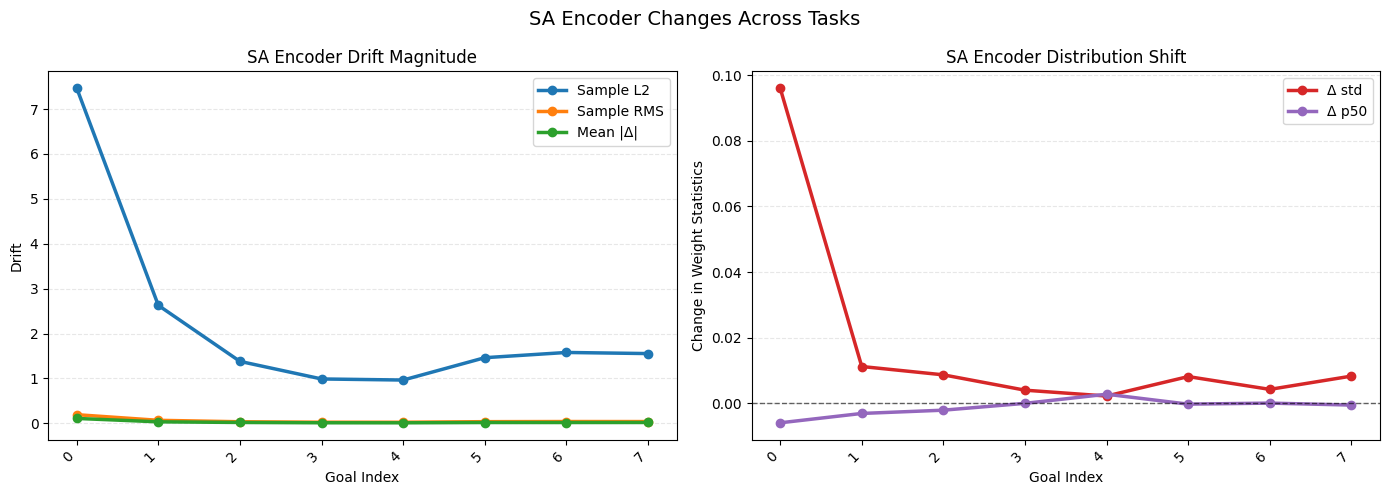

In [11]:
plot_sa_encoder_changes_across_tasks(overall_results)

In [12]:
# ============================================================
# Retraining / adaptation from saved sequential model
# ============================================================

ADAPT_TOTAL_STEPS = 30_000
ADAPT_WARMUP_STEPS = 1_000
ADAPT_BATCH_SIZE = 256
ADAPT_LR = 1e-3

ADAPT_GAMMA = 0.99
ADAPT_TAU = 0.005

ADAPT_EPS_START = 0.3
ADAPT_EPS_END = 0.05
ADAPT_EPS_DECAY_STEPS = 10_000
ADAPT_TRAIN_FREQ = 4


num_tasks = NUM_GOALS


# Results are stored by seed and task index
adaptation_results = {
    seed: {
        "scratch": {},
        "sa_transfer": {},
    }
    for seed in SEEDS
}


for seed in SEEDS:
    print(
        f"\n================ ADAPTATION "
        f"SEED {seed} ================\n"
    )

    # Goals sampled specifically for this seed
    seed_goals = goals_by_seed[seed]

    # Final sequentially trained network for this seed
    final_q = final_q_networks[seed]


    for task_idx, goal in enumerate(seed_goals):
        task_label = f"Task {task_idx}"

        print(
            f"\n----- seed={seed}, "
            f"task_idx={task_idx}, "
            f"goal={goal} -----\n"
        )


        adapt_seed = (
            seed
            + 10000
            + task_idx
        )


        env_tmp = make_env(
            goal=goal
        )

        obs_dim = int(
            env_tmp.observation_space.shape[0]
        )

        num_actions = int(
            env_tmp.action_space.n
        )

        env_tmp.close()


        # ====================================================
        # Scratch model
        # ====================================================
        set_seed(adapt_seed)


        scratch_q = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)


        scratch_target = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)


        scratch_target.load_state_dict(
            scratch_q.state_dict()
        )


        for p in scratch_q.parameters():
            p.requires_grad_(True)


        for p in scratch_target.parameters():
            p.requires_grad_(False)


        scratch_env = make_env(
            goal=goal
        )


        (
            scratch_q,
            scratch_target,
            scratch_returns,
            scratch_steps,
            scratch_time,
            scratch_task_embedding,
            scratch_sa_mean,
            scratch_sa_fixed,
            scratch_sa_batch,
            scratch_buffer,
        ) = dqn_train_new(
            seed=adapt_seed,
            q_network=scratch_q,
            q_target_network=scratch_target,
            env=scratch_env,
            make_env=make_env,

            buffer_capacity=BUFFER_CAPACITY,
            lr=ADAPT_LR,
            obs_dim=obs_dim,
            device=DEVICE,

            total_steps=ADAPT_TOTAL_STEPS,
            warmup_steps=ADAPT_WARMUP_STEPS,
            batch_size=ADAPT_BATCH_SIZE,

            gamma=ADAPT_GAMMA,
            tau=ADAPT_TAU,

            eps_start=ADAPT_EPS_START,
            eps_end=ADAPT_EPS_END,
            eps_decay_steps=ADAPT_EPS_DECAY_STEPS,
            train_freq=ADAPT_TRAIN_FREQ,

            goal=goal,
            td_steps=1,

            embedding_memory={
                "sa_anchors": [],
            },

            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,

            use_sa_stability=False,
            project_sa_gradients=False,
            lambda_sa_stability=0.0,
        )


        if hasattr(scratch_env, "close"):
            scratch_env.close()


        # ====================================================
        # SA-transfer model
        # ====================================================
        set_seed(adapt_seed)


        transfer_q = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)


        transfer_target = FactorisedDQN_QNetwork(
            obs_dim=obs_dim,
            num_actions=num_actions,
            goal_dim=2,
            hidden_dim=128,
            rep_dim=64,
        ).to(DEVICE)


        # Transfer the complete final sequential model
        transfer_q.load_state_dict(
            final_q.state_dict()
        )


        # Freeze phi(s,a)
        for p in transfer_q.sa_encoder.parameters():
            p.requires_grad_(False)


        # Keep psi(g) trainable
        for p in transfer_q.goal_encoder.parameters():
            p.requires_grad_(True)


        # Target starts from the transferred model
        transfer_target.load_state_dict(
            transfer_q.state_dict()
        )


        for p in transfer_target.parameters():
            p.requires_grad_(False)


        transfer_params = [
            p
            for p in transfer_q.goal_encoder.parameters()
            if p.requires_grad
        ]


        transfer_env = make_env(
            goal=goal
        )


        (
            transfer_q,
            transfer_target,
            transfer_returns,
            transfer_steps,
            transfer_time,
            transfer_task_embedding,
            transfer_sa_mean,
            transfer_sa_fixed,
            transfer_sa_batch,
            transfer_buffer,
        ) = dqn_train_new(
            seed=adapt_seed,
            q_network=transfer_q,
            q_target_network=transfer_target,
            env=transfer_env,
            make_env=make_env,

            buffer_capacity=BUFFER_CAPACITY,
            lr=ADAPT_LR,
            obs_dim=obs_dim,
            device=DEVICE,

            total_steps=ADAPT_TOTAL_STEPS,
            warmup_steps=ADAPT_WARMUP_STEPS,
            batch_size=ADAPT_BATCH_SIZE,

            gamma=ADAPT_GAMMA,
            tau=ADAPT_TAU,

            eps_start=ADAPT_EPS_START,
            eps_end=ADAPT_EPS_END,
            eps_decay_steps=ADAPT_EPS_DECAY_STEPS,
            train_freq=ADAPT_TRAIN_FREQ,

            goal=goal,
            td_steps=1,

            params=transfer_params,

            embedding_memory={
                "sa_anchors": [],
            },

            early_stop_reward=0.99,
            early_stop_patience=3,
            enable_early_stop=True,

            use_sa_stability=False,
            project_sa_gradients=False,
            lambda_sa_stability=0.0,
        )


        if hasattr(transfer_env, "close"):
            transfer_env.close()


        # ====================================================
        # Save results by task index
        # ====================================================
        adaptation_results[seed]["scratch"][task_idx] = {
            "goal": goal,
            "eval_returns": scratch_returns,
            "min_steps": scratch_steps,
            "min_time": scratch_time,
            "task_embedding": scratch_task_embedding,
            "sa_embedding": scratch_sa_mean,
            "sa_fixed_probe_embedding": scratch_sa_fixed,
            "sa_batch_final": scratch_sa_batch,
        }


        adaptation_results[seed]["sa_transfer"][task_idx] = {
            "goal": goal,
            "eval_returns": transfer_returns,
            "min_steps": transfer_steps,
            "min_time": transfer_time,
            "task_embedding": transfer_task_embedding,
            "sa_embedding": transfer_sa_mean,
            "sa_fixed_probe_embedding": transfer_sa_fixed,
            "sa_batch_final": transfer_sa_batch,
        }


        print(
            f"{task_label} | "
            f"goal={goal} | "
            f"scratch steps={scratch_steps} | "
            f"SA transfer steps={transfer_steps} | "
            f"scratch time={scratch_time:.2f}s | "
            f"SA transfer time={transfer_time:.2f}s"
        )


# ============================================================
# Aggregate adaptation results
# ============================================================

num_seeds = len(SEEDS)
num_tasks = NUM_GOALS


scratch_steps = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

transfer_steps = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

scratch_times = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)

transfer_times = np.full(
    (num_seeds, num_tasks),
    np.nan,
    dtype=np.float32,
)


for seed_idx, seed in enumerate(SEEDS):
    for task_idx in range(num_tasks):

        scratch_result = (
            adaptation_results[seed]
            ["scratch"]
            [task_idx]
        )

        transfer_result = (
            adaptation_results[seed]
            ["sa_transfer"]
            [task_idx]
        )


        scratch_steps[
            seed_idx,
            task_idx,
        ] = float(
            scratch_result["min_steps"]
        )

        transfer_steps[
            seed_idx,
            task_idx,
        ] = float(
            transfer_result["min_steps"]
        )

        scratch_times[
            seed_idx,
            task_idx,
        ] = float(
            scratch_result["min_time"]
        )

        transfer_times[
            seed_idx,
            task_idx,
        ] = float(
            transfer_result["min_time"]
        )


# ============================================================
# Aggregate statistics across seeds
# ============================================================

scratch_steps_mean = np.nanmean(
    scratch_steps,
    axis=0,
)

scratch_steps_std = np.nanstd(
    scratch_steps,
    axis=0,
)

transfer_steps_mean = np.nanmean(
    transfer_steps,
    axis=0,
)

transfer_steps_std = np.nanstd(
    transfer_steps,
    axis=0,
)

scratch_times_mean = np.nanmean(
    scratch_times,
    axis=0,
)

scratch_times_std = np.nanstd(
    scratch_times,
    axis=0,
)

transfer_times_mean = np.nanmean(
    transfer_times,
    axis=0,
)

transfer_times_std = np.nanstd(
    transfer_times,
    axis=0,
)


# ============================================================
# Print results by task index
# ============================================================

print(
    "\n========== ADAPTATION RESULTS "
    "BY TASK INDEX ==========\n"
)


for task_idx in range(num_tasks):
    print(
        f"Task {task_idx} | "
        f"scratch steps="
        f"{scratch_steps_mean[task_idx]:.1f} "
        f"+/- "
        f"{scratch_steps_std[task_idx]:.1f} | "
        f"SA-transfer steps="
        f"{transfer_steps_mean[task_idx]:.1f} "
        f"+/- "
        f"{transfer_steps_std[task_idx]:.1f} | "
        f"scratch time="
        f"{scratch_times_mean[task_idx]:.2f}s "
        f"+/- "
        f"{scratch_times_std[task_idx]:.2f}s | "
        f"SA-transfer time="
        f"{transfer_times_mean[task_idx]:.2f}s "
        f"+/- "
        f"{transfer_times_std[task_idx]:.2f}s"
    )


# ============================================================
# Overall metrics
# ============================================================

print(
    "\n========== OVERALL ADAPTATION METRICS ==========\n"
)

print(
    f"Mean scratch steps: "
    f"{np.nanmean(scratch_steps):.1f}"
)

print(
    f"Mean SA-transfer steps: "
    f"{np.nanmean(transfer_steps):.1f}"
)

print(
    f"Mean scratch time: "
    f"{np.nanmean(scratch_times):.2f}s"
)

print(
    f"Mean SA-transfer time: "
    f"{np.nanmean(transfer_times):.2f}s"
)


# Positive values mean that SA transfer used fewer steps
step_reduction = (
    scratch_steps
    - transfer_steps
)

step_reduction_mean = np.nanmean(
    step_reduction,
    axis=0,
)

step_reduction_std = np.nanstd(
    step_reduction,
    axis=0,
)


print(
    "\n========== SA-TRANSFER STEP REDUCTION "
    "BY TASK ==========\n"
)

for task_idx in range(num_tasks):
    print(
        f"Task {task_idx} | "
        f"step reduction="
        f"{step_reduction_mean[task_idx]:.1f} "
        f"+/- "
        f"{step_reduction_std[task_idx]:.1f}"
    )


================ ADAPTATION SEED 42 ================


----- seed=42, task_idx=0, goal=(8, 9) -----



TypeError: dqn_train_new() got an unexpected keyword argument 'lr'

## HTML visualisation

In [ ]:
for goal, data in overall_results.items():
    print(goal)
    print("task_embeddings:", len(data.get("task_embeddings", [])))
    print("sa_fixed_probe_embeddings:", len(data.get("sa_fixed_probe_embeddings", [])))
    print("sa_batches_final:", len(data.get("sa_batches_final", [])))

dashboard = plot_full_embedding_dashboard_html(
    overall_results=overall_results,
    qnet=q_network,
    mode="all",
    save_html="plots/full_embedding_dashboard_maze.html",
    weights_his=weight_history,
)

print(dashboard["save_html"])
print(dashboard["isotropy_metrics"])